# LAB exam assignment 1


# Task A: Data Audit & Quality

## Data Dictionary

Quick reference for all columns in `marketing_campaign.csv`. 
Types reflect actual dtypes in the loaded DataFrame.

---

## `marketing_campaign.csv` — Customer Profile

| Column | Type | Description |
|---|---|---|
| `ID` | integer | Unique identifier for each customer |
| `Year_Birth` | integer | Customer's birth year |
| `Education` | string | Customer's education level (`Basic`, `2n Cycle`, `Graduation`, `Master`, `PhD`) |
| `Marital_Status` | string | Customer's marital status (`Single`, `Married`, `Together`, `Divorced`, `Widow`) |
| `Income` | float | Customer's yearly household income in - I suppose - dollars |
| `Kidhome` | integer | Number of small children in the customer's household |
| `Teenhome` | integer | Number of teenagers in the customer's household |
| `Dt_Customer` | string (date) | Date of customer's enrollment with the company |
| `Recency` | integer | Number of days since the customer's last purchase |

---

## `marketing_campaign.csv` — Spending Behaviour

| Column | Type | Description |
|---|---|---|
| `MntWines` | integer | Amount spent on wine in the last 2 years ($) |
| `MntFruits` | integer | Amount spent on fruits in the last 2 years ($) |
| `MntMeatProducts` | integer | Amount spent on meat in the last 2 years ($) |
| `MntFishProducts` | integer | Amount spent on fish in the last 2 years ($) |
| `MntSweetProducts` | integer | Amount spent on sweets in the last 2 years ($) |
| `MntGoldProds` | integer | Amount spent on gold products in the last 2 years ($) |

---

## `marketing_campaign.csv` — Purchase Channels

| Column | Type | Description |
|---|---|---|
| `NumDealsPurchases` | integer | Number of purchases made with a discount |
| `NumWebPurchases` | integer | Number of purchases made through the company's website |
| `NumCatalogPurchases` | integer | Number of purchases made using a catalogue |
| `NumStorePurchases` | integer | Number of purchases made directly in stores |
| `NumWebVisitsMonth` | integer | Number of visits to the company's website in the last month |

---

## `marketing_campaign.csv` — Campaign Responses

| Column | Type | Description |
|---|---|---|
| `AcceptedCmp1` | integer | `1` if customer accepted the offer in the 1st campaign, `0` otherwise |
| `AcceptedCmp2` | integer | `1` if customer accepted the offer in the 2nd campaign, `0` otherwise |
| `AcceptedCmp3` | integer | `1` if customer accepted the offer in the 3rd campaign, `0` otherwise |
| `AcceptedCmp4` | integer | `1` if customer accepted the offer in the 4th campaign, `0` otherwise |
| `AcceptedCmp5` | integer | `1` if customer accepted the offer in the 5th campaign, `0` otherwise |
| `Complain` | integer | `1` if customer complained in the last 2 years, `0` otherwise |
| `Response` | integer | `1` if customer accepted the offer in the **last** campaign, `0` otherwise |

## Setup
Importing required libraries and loading `marketing_campaign.csv` 
(separator: `;`, shape: 2,240 rows × 27 columns).

### Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep=';')

print("Marketing Data shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Marketing Data shape: (2240, 27)

Column names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


### Structural Overview
Variable types, missing values, and duplicate records.

In [4]:
print("--- Marketing Campaign Dataset Info ---")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

--- Marketing Campaign Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15

### Categorical Columns — Value Validation

In [5]:
cat_cols = ['Education', 'Marital_Status']

for col in cat_cols:
    display(
        df[col].value_counts()
        .rename_axis(col)
        .reset_index(name='Count')
        .style.set_caption(f"{col} — Value Counts")
        .set_table_styles([{'selector': 'caption', 
                            'props': [('font-weight', 'bold'), 
                                      ('font-size', '14px')]}])
        .bar(subset=['Count'], color='#4c8cbf', vmin=0)
    )

,Education,Count
0,Graduation,1127
1,PhD,486
2,Master,370
3,2n Cycle,203
4,Basic,54


,Marital_Status,Count
0,Married,864
1,Together,580
2,Single,480
3,Divorced,232
4,Widow,77
5,Alone,3
6,Absurd,2
7,YOLO,2


In [6]:
df[['Income']].describe().T.map(lambda x: f"{x:,.0f}") \
    .style.set_caption("Income — Descriptive Statistics") \
    .set_table_styles([{'selector': 'caption', 
                        'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

,count,mean,std,min,25%,50%,75%,max
Income,"2,216","52,247","25,173","1,730","35,303","51,382","68,522","666,666"


In [7]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df[spend_cols].describe().T.map(lambda x: f"{x:,.0f}") \
    .style.set_caption("Spending Behaviour — Descriptive Statistics") \
    .set_table_styles([{'selector': 'caption', 
                        'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

,count,mean,std,min,25%,50%,75%,max
MntWines,"2,240",304,337,0,24,174,504,"1,493"
MntFruits,"2,240",26,40,0,1,8,33,199
MntMeatProducts,"2,240",167,226,0,16,67,232,"1,725"
MntFishProducts,"2,240",38,55,0,3,12,50,259
MntSweetProducts,"2,240",27,41,0,1,8,33,263
MntGoldProds,"2,240",44,52,0,9,24,56,362


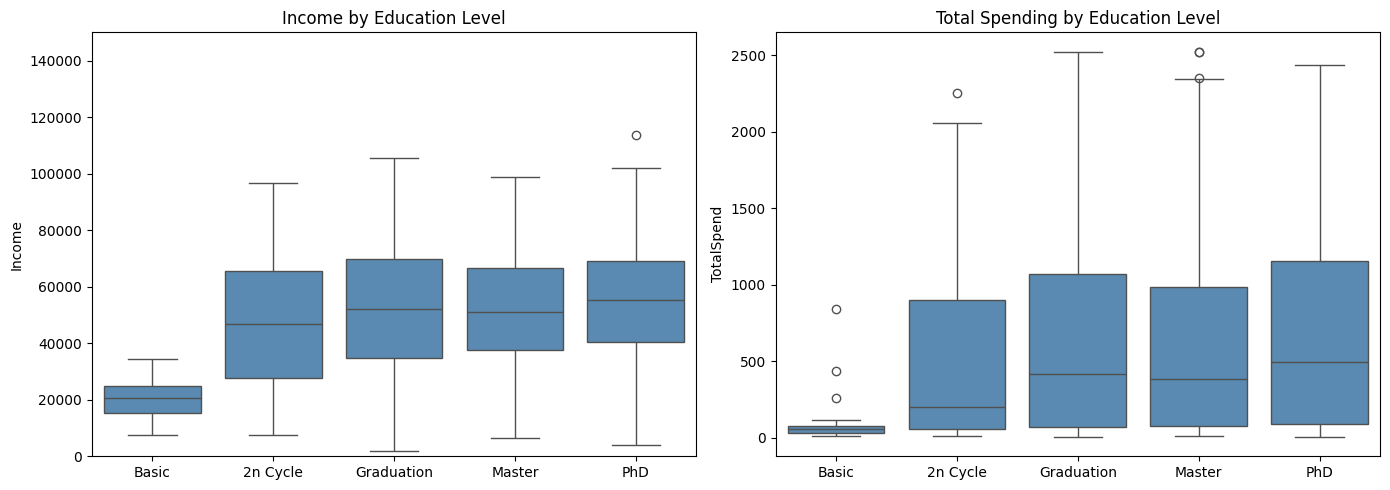

In [8]:
# Define order and derived column here so cell is self-contained
edu_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']

df['TotalSpend'] = df[['MntWines', 'MntFruits', 'MntMeatProducts',
                        'MntFishProducts', 'MntSweetProducts', 
                        'MntGoldProds']].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Education', y='Income', 
            order=edu_order, ax=axes[0], color='#4c8cbf')
axes[0].set_ylim(0, 150000)
axes[0].set_title('Income by Education Level')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='Education', y='TotalSpend', 
            order=edu_order, ax=axes[1], color='#4c8cbf')
axes[1].set_title('Total Spending by Education Level')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [9]:
# Numerical summary to support grouping decision
summary = df.groupby('Education')[['Income', 'TotalSpend']].agg(['median', 'mean']) \
            .reindex(edu_order)

summary.columns = ['Income Median', 'Income Mean', 'Spend Median', 'Spend Mean']

display(
    summary.style
    .format({'Income Median': '€{:,.0f}', 'Income Mean': '€{:,.0f}',
             'Spend Median':  '€{:,.0f}', 'Spend Mean':  '€{:,.0f}'})
    .set_caption("Income & Spending by Education Level")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'), ('font-size', '14px')]}])
    .bar(subset=['Income Median', 'Spend Median'], color='#4c8cbf', vmin=0)
)

,Income Median,Income Mean,Spend Median,Spend Mean
Education,,,,
Basic,"€20,744","€20,306",€57,€82
2n Cycle,"€46,805","€47,633",€198,€497
Graduation,"€52,028","€52,720",€414,€620
Master,"€50,943","€52,918",€388,€612
PhD,"€55,212","€56,145",€493,€672


### 1.3 Audit Findings Summary

**Marketing Campaign Dataset:**

- `Income` is the only column with missing values: exactly 24 null entries (~1.07% of the data)

- `Dt_Customer` is stored as `object` (string). It refers to the date on which the customer was enrolled in the database and therefore needs to be converted to `datetime` to be usable for time-based analysis

- `Education` and `Marital_Status` are stored as `object` (string), which is the correct type, but inspection reveals **invalid category values** in `Marital_Status`: `'Absurd'`, `'YOLO'` (2 entries each) and `'Alone'` (3 entries, likely a duplicate of `'Single'`) that need to be handled

- `'2n Cycle'` in `Education` (likely a typo for `'2nd Cycle'`) presented an interpretive 
  ambiguity to me: under the Bologna Process framework, the 2nd cycle corresponds to Master's 
  level, which would suggest merging it with `'Master'`. However, rather than relying on 
  assumptions, I verified this empirically by comparing median income and spending across 
  education levels. The results show that `'2n Cycle'` customers have a median income of 
  €46,805 and a median total spend of €198 — both substantially below `'Graduation'` 
  (€52,028 / €414) and `'Master'` (€50,943 / €388). This places `'2n Cycle'` closer to 
  a sub-bachelor level, so I decided **not** to merge it with `'Master'` and to retain 
  it as a distinct category below `'Graduation'`.



- `Income` carries no currency label either in the raw data or in the assignment 
  description, which simply states "Customer's yearly household income". To investigate 
  the likely unit, I examined the descriptive statistics: the median is 51,382 and the 
  mean is 52,247. Comparing these with national median household incomes around 2012 — 
  the period reflected in the enrollment dates — European countries fall well below this 
  range (e.g. France ~€36,000, Germany ~€33,400, Spain ~€23,700). The US median household 
  income in 2012 was approximately $51,000, which aligns almost exactly with this dataset's 
  median. This suggests values are more likely denominated in **USD**. However, since the 
  currency cannot be confirmed from the data alone, I will treat the unit as a generic 
  monetary value throughout the analysis without assuming a specific currency symbol.

- All spending and purchase columns are correctly typed as `int64`

- No duplicate rows were detected

## Addressing Missing Values and Outliers

First, let's cast incorrect data types to see if structural errors turn into missing values.
We start from `Dt_Customer` since we know it should be a date but is stored as object.
We first inspect the raw values to identify the format, then convert accordingly.

In [10]:
print(df['Dt_Customer'].head(5))

0    2012-09-04
1    2014-03-08
2    2013-08-21
3    2014-02-10
4    2014-01-19
Name: Dt_Customer, dtype: object


Output confirms format is YYYY-MM-DD , so we use format='%Y-%m-%d'

The `Dt_Customer` column records the date on which each customer was enrolled 
in the company. Rather than keeping it as a raw date, I decided to use it to 
derive the **age of the customer** at the time they were active in the dataset 
— since age is a more interpretable socio-demographic feature for segmentation 
and spending analysis than an enrollment date. As a first step, I converted 
`Dt_Customer` from `object` to `datetime64`, confirming the format as `YYYY-MM-DD`.

To compute age, I needed a reference year to subtract from `Year_Birth`. 
I considered two approaches: using today's date, which is simple but would make 
customers appear significantly older than they actually were when their purchasing 
decisions were recorded, distorting any analysis linking age to spending behaviour. 
Instead, I chose to use the **most recent enrollment date present in the dataset** 
as a proxy for the data collection cutoff. This anchors age to the period the data 
actually covers, and has the advantage of being derived directly from the data 
itself rather than relying on an external, arbitrary date.

In this dataset, the most recent enrollment date is **June 2014**, 
so I used **2014 as the reference year**.

In [11]:
# Convert to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%Y-%m-%d')

# We don't know the exact data collection date.
# We use the most recent record in the dataset as a reference point,
# so that Age reflects how old customers were during the period the data covers.
reference_year = df['Dt_Customer'].dt.year.max()
print("Reference year used:", reference_year)


Reference year used: 2014


In [12]:
# Compute Age relative to that reference year
df['Age'] = reference_year - df['Year_Birth']

# Verify the conversion worked — check dtype, not missing values
print("Dt_Customer dtype after conversion:", df['Dt_Customer'].dtype)
print("Age dtype:", df['Age'].dtype)
print("\nSample:")
print(df[['Dt_Customer', 'Age']].head(3))

Dt_Customer dtype after conversion: datetime64[ns]
Age dtype: int64

Sample:
  Dt_Customer  Age
0  2012-09-04   57
1  2014-03-08   60
2  2013-08-21   49


we do now check that the conversion worked and we didn't introduce new nulls.

In [13]:
# Verify conversion didn't introduce new nulls
print(f"Dt_Customer — dtype: {df['Dt_Customer'].dtype}, nulls: {df['Dt_Customer'].isna().sum()}")
print(f"Age          — dtype: {df['Age'].dtype},          nulls: {df['Age'].isna().sum()}")

Dt_Customer — dtype: datetime64[ns], nulls: 0
Age          — dtype: int64,          nulls: 0


### identifying outliers

Next, let's look at the distributions of numeric features to identify outliers.

,count,mean,std,min,25%,50%,75%,max
Age,"2,240.00",45.19,11.98,18.00,37.00,44.00,55.00,121.00
Income,"2,216.00","52,247.25","25,173.08","1,730.00","35,303.00","51,381.50","68,522.00","666,666.00"


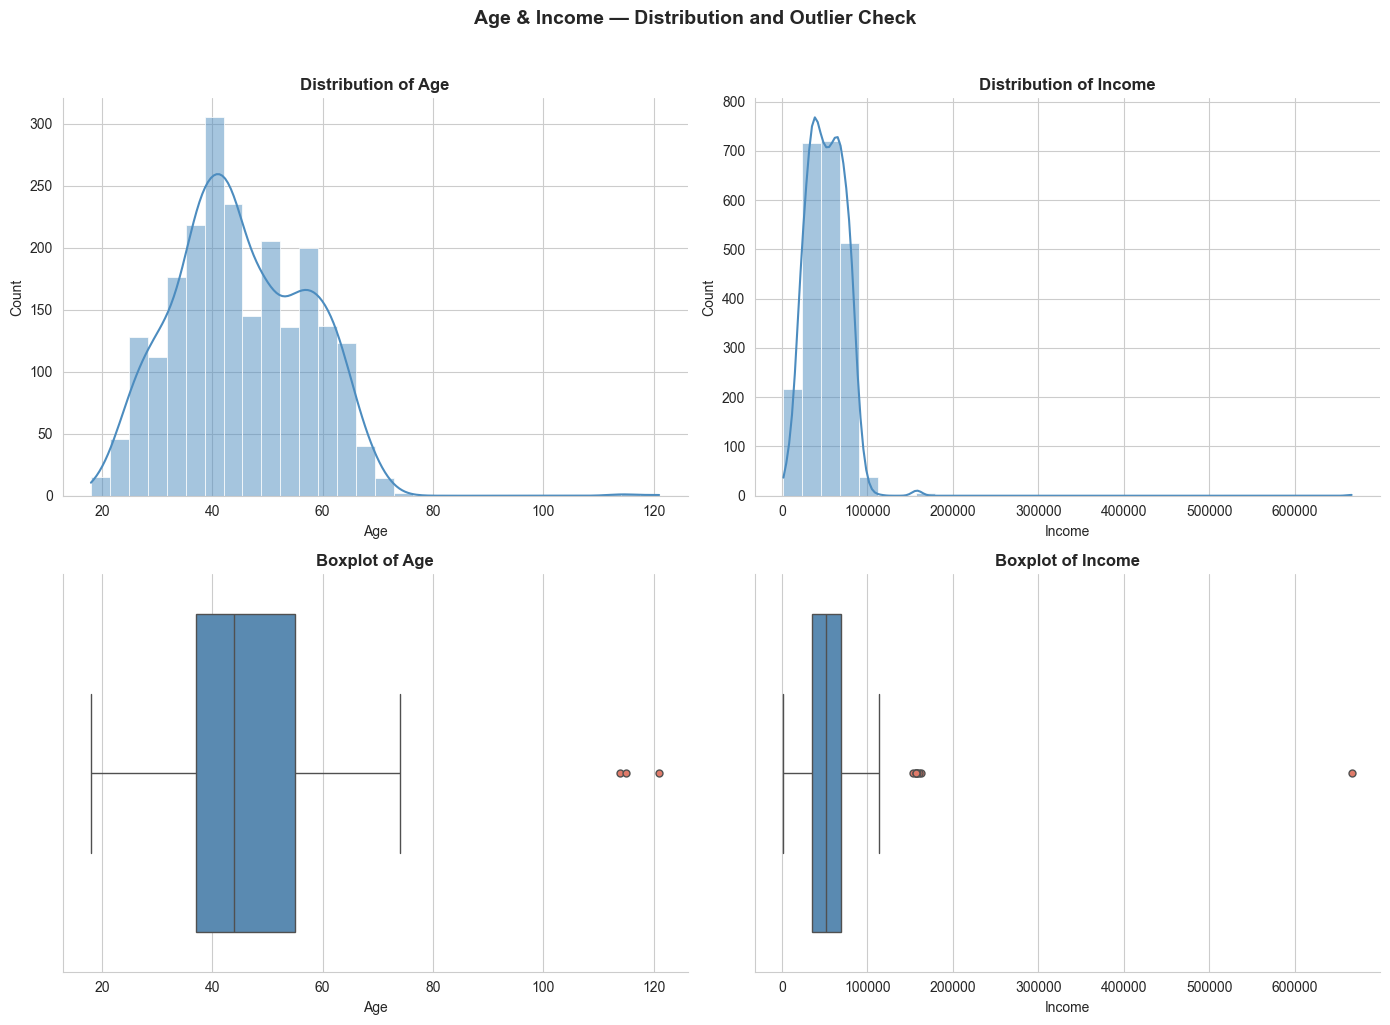

In [14]:
# Set consistent style for the whole notebook
sns.set_style("whitegrid")
sns.set_palette([BLUE := "#4c8cbf"])

cols_to_analyze = ['Age', 'Income']

display(
    df[cols_to_analyze].describe().T \
        .style \
        .format('{:,.2f}') \
        .set_caption("Age & Income — Descriptive Statistics") \
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-weight', 'bold'), 
                                      ('font-size', '14px')]}]) \
        .bar(subset=['mean', '50%'], color='#4c8cbf', vmin=0)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Age & Income — Distribution and Outlier Check', 
             fontsize=14, fontweight='bold', y=1.02)

# Histograms
for i, col in enumerate(cols_to_analyze):
    data = df[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=axes[0, i], 
                 color='#4c8cbf', edgecolor='white', linewidth=0.5)
    axes[0, i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')
    axes[0, i].spines[['top', 'right']].set_visible(False)

# Boxplots
for i, col in enumerate(cols_to_analyze):
    sns.boxplot(x=df[col].dropna(), ax=axes[1, i],
                color='#4c8cbf', flierprops=dict(marker='o', 
                markerfacecolor='#e07b6a', markersize=5))
    axes[1, i].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[1, i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


### Justification of Cleaning Strategy

**1. Missing Values (`Income`):**

`Income` has 24 missing values (~1.07%). Instead of relying on a generalized global metric, we impute these missing values using the **median `Income` grouped by `Education` level**. This approach preserves the underlying socio-demographic variance of the dataset, providing a mathematically tighter estimate tailored to the customer's specific academic tier. We utilize the median rather than the mean for these sub-groups because income distributions are inherently right-skewed, making the median far more robust to extreme high-earners within any given education bracket.

**1. Missing Values**

**(`Income`):**
Following the missing data framework covered in the course, missing values can be 
classified as Missing Completely At Random (MCAR), Missing At Random (MAR), or 
Missing Not At Random (MNAR). With only 24 missing entries (~1.07%), MCAR cannot 
be ruled out. However, since income is a sensitive variable and higher earners may 
be less likely to report it, MNAR is also plausible — though this cannot be 
verified from the data alone. I therefore adopt a MAR assumption, which justifies 
imputation rather than deletion. Rather than using a global median, I impute using 
the **median `Income` grouped by `Education` level**, as this provides a more 
accurate estimate tailored to each customer's socio-demographic bracket. The median 
is preferred over the mean since income distributions are inherently right-skewed.

**2. Categorical Consolidation & Invalid Values:**

**`Marital_Status`:** `'Alone'` (3 entries) functionally aligns with `'Single'` and will be recoded. `'Absurd'` and `'YOLO'` (2 entries each) are logically invalid anomalies that cannot be meaningfully imputed; therefore, these rows will be dropped.

**3. Outliers (`Age`, `Income`):**
When addressing outliers, it is critical to distinguish between extreme values that represent data corruption (which distort analysis) and values that are genuinely extreme but reflect reality (which hold analytical value and should be preserved).

* **`Age`:** The boxplot reveals customers with an `Age` > 90, indicating birth years prior to 1934. In the context of a modern retail database, these are almost certainly data entry errors or default placeholder values and will be dropped.

- **`Income`:** A severe extreme value of 666,666 is visible in the visualizations, 
  sitting far detached from the overall distribution — the 3rd quartile is only 68,522, 
  placing this value nearly 9× above Q3. While an income of ~$666,000 is not impossible 
  in absolute terms, the repeating digit pattern (666,666) strongly suggests a placeholder 
  or data entry error rather than a genuine high earner. This aligns with the first type 
  of outlier: **data error** — a value that is not representative of reality and should 
  not be preserved.

  To isolate and remove it without damaging the integrity of the data, I apply the IQR 
  method with a conservative 3× multiplier. This strictly targets the truly anomalous 
  entry while safely preserving the legitimate high-net-worth customers clustered in the 
  right tail of the distribution.

  It is also worth noting that, if the value were genuine, this customer's behaviour 
could represent an interesting case in its own right — a high-net-worth outlier 
whose spending patterns may differ substantially from the rest of the customer base. 
In a real business context, such a customer might warrant a separate analysis rather 
than removal.


Before removing this observation, I examined its spending profile to assess 
whether it could represent a genuine high-net-worth customer. In a real business 
context, an ultra-high-income customer might warrant individual treatment rather 
than removal — however, this reasoning only holds if their spending reflects 
their income. I therefore compare this customer's spending directly against the 
dataset median and maximum to determine whether their behaviour is consistent 
with a genuine high earner.

In [15]:
# Compare outlier spending vs dataset median
outlier = df[df['Income'] == 666666]
spend_cols = ['MntWines', 'MntMeatProducts', 'MntGoldProds', 'TotalSpend']

comparison = pd.DataFrame({
    'Outlier': outlier[spend_cols].values[0],
    'Dataset Median': df[spend_cols].median(),
    'Dataset Max': df[spend_cols].max()
}, index=spend_cols)

display(comparison.style
    .format('{:,.0f}')
    .set_caption("Outlier Customer vs Dataset — Spending Comparison")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'), 
                                  ('font-size', '14px')]}]))

,Outlier,Dataset Median,Dataset Max
MntWines,9,174,"1,493"
MntMeatProducts,18,67,"1,725"
MntGoldProds,12,24,362
TotalSpend,62,396,"2,525"


The results are unambiguous. Despite an income of $666,666 — approximately 
13× the dataset median of ~$51,000 — this customer's TotalSpend is only €62, 
which is **6× below the dataset median** of €396 and less than 3% of the 
maximum observed spending (€2,525). A genuine high-net-worth customer would 
be expected to show at least proportionally elevated spending across categories. 
Instead, this customer spends less than the average customer in every single 
category — €9 on wine vs. a median of €174, €18 on meat vs. a median of €67.

This spending profile is entirely inconsistent with a genuine high earner and 
**confirms the data entry error hypothesis**. I therefore proceed with removal.

In [16]:
df['Marital_Status'] = df['Marital_Status'].replace('Alone', 'Single') # replace alone with single

# Remove rows with invalid Marital_Status values
df = df[~df['Marital_Status'].isin(['Absurd', 'YOLO'])]

# .groupby('Education') → splits customers into education-level groups
# .transform('median')  → returns the group median for every row (same length as df)
# .fillna(...)          → only fills NaN values, leaving existing values untouched
df['Income'] = df['Income'].fillna(
    df.groupby('Education')['Income'].transform('median')
)
# --- Remove Age outliers (unrealistic birth years) ---
df = df[df['Age'] <= 90]

# --- Remove Income outlier ---
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

upper_fence = Q3 + 3 * IQR

# Print fence for transparency before filtering
print(f"IQR upper fence (3×): €{upper_fence:,.0f}")
print(f"Values to be removed: {(df['Income'] > upper_fence).sum()}")

df = df[df['Income'] <= upper_fence]

print(f"Clean dataset shape: {df.shape}")
print(f"\nMarital_Status values: {df['Marital_Status'].unique()}")
print(f"Age range: {df['Age'].min()} → {df['Age'].max()}")
print(f"Income range: €{df['Income'].min():,.0f} → €{df['Income'].max():,.0f}")

IQR upper fence (3×): €166,801
Values to be removed: 1
Clean dataset shape: (2232, 29)

Marital_Status values: ['Single' 'Together' 'Married' 'Divorced' 'Widow']
Age range: 18 → 74
Income range: €1,730 → €162,397


### Check of the Variables After Cleaning

,mean,std,min,25%,50%,75%,max
Age,45.11,11.70,18,37,44,55,74
Income,"51,941.84","21,422.05","1,730","35,435","51,446","68,276","162,397"


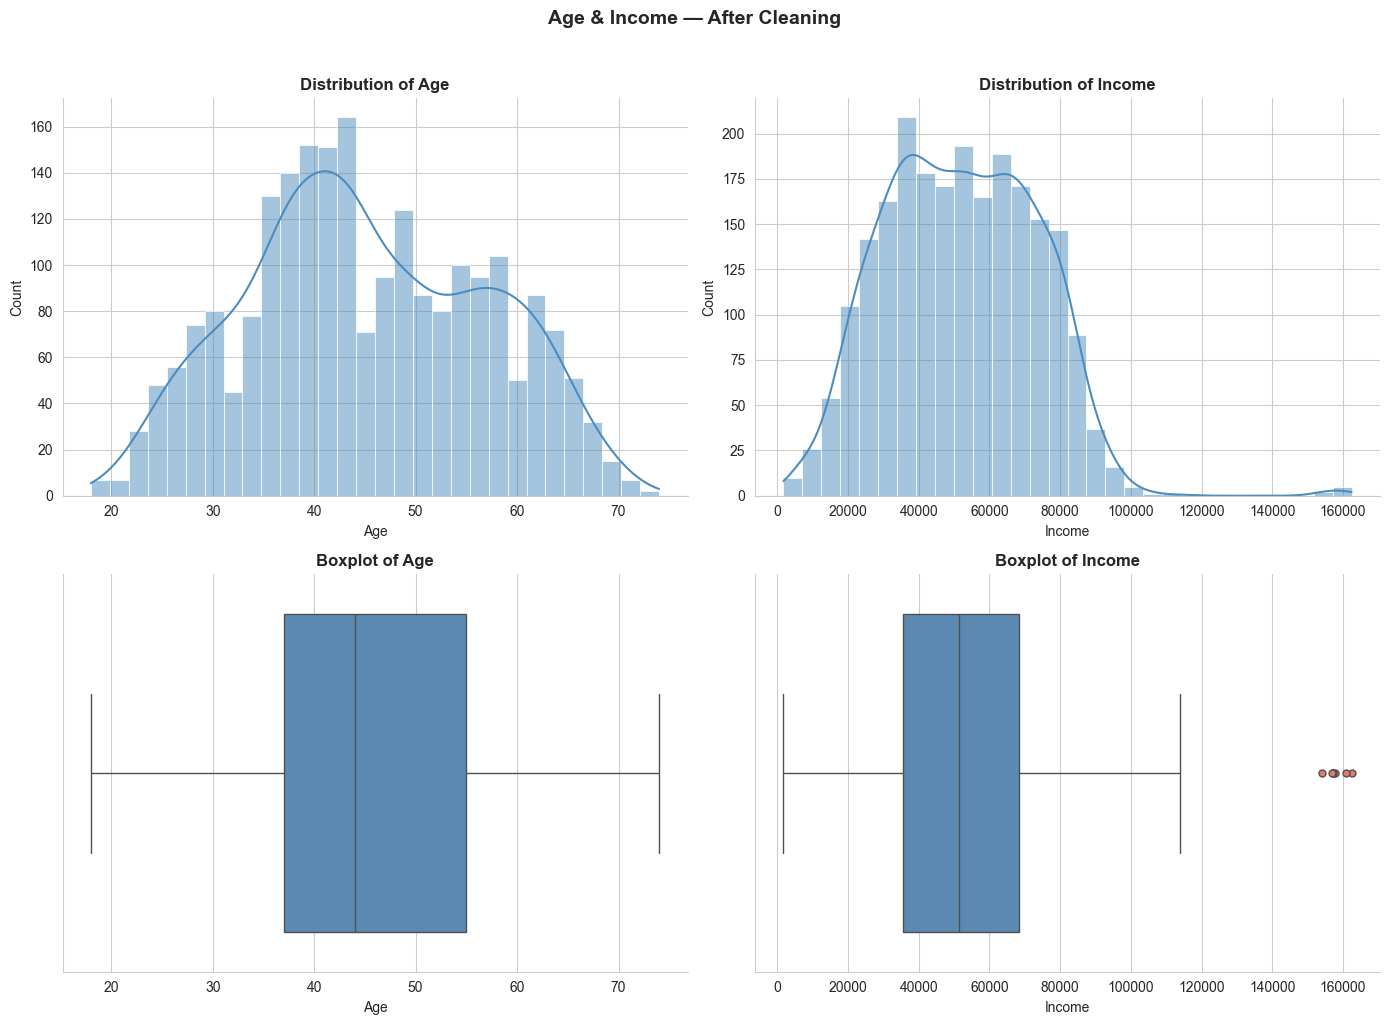

In [17]:
# Re-run the same plots on the cleaned dataset to verify outliers were removed
# and distributions look reasonable
cols_to_analyze = ['Age', 'Income']

# Styled summary table
display(
    df[cols_to_analyze].describe().drop('count').T
    .style
    .format({'mean': '{:,.2f}', 'std': '{:,.2f}',
             'min': '{:,.0f}', '25%': '{:,.0f}',
             '50%': '{:,.0f}', '75%': '{:,.0f}',
             'max': '{:,.0f}'})
    .set_caption("Age & Income — Descriptive Statistics After Cleaning")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'),
                                  ('font-size', '14px')]}])
)

# Distributions and boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Age & Income — After Cleaning', 
             fontsize=14, fontweight='bold', y=1.02)

for i, col in enumerate(cols_to_analyze):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0, i],
                 color='#4c8cbf', edgecolor='white', linewidth=0.5)
    axes[0, i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[0, i].spines[['top', 'right']].set_visible(False)

    sns.boxplot(x=df[col], ax=axes[1, i],
                color='#4c8cbf',
                flierprops=dict(marker='o', 
                               markerfacecolor='#e07b6a', 
                               markersize=5))
    axes[1, i].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[1, i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Task B: Exploratory Data Analysis (EDA)

The goal of this section is to understand the structure and patterns in the 
cleaned dataset before modelling. I follow three lines of inquiry as specified 
in the assignment:

1. **Socio-demographic correlations** — how do Age, Income, Education, 
   household composition (children, partner) relate to total spending?
2. **Purchase channel distribution** — where do customers buy, and who buys where?
3. **Communication Insight** — one hidden trend that could inform a targeted 
   promotional campaign.

Before the analysis, I derive a set of engineered features from the cleaned 
dataset: `TotalSpending` (sum of all product categories), `TotalKids` 
(children + teenagers), `TotalPurchases` (web + catalogue + store), 
`Seniority` (days since enrollment), `Education_enc` (ordinal encoding), 
and `IsPartnered` (binary: Married/Together vs rest). 

In [18]:
# Total amount spent across all product categories
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpending'] = df[spending_cols].sum(axis=1)
# axis=1 sums across columns → one total per customer row

# Total number of children at home (small children + teenagers)
# Kept combined for household size analysis; originals retained for age-specific use
df['TotalKids'] = df['Kidhome'] + df['Teenhome']

# Total purchases across all channels
# Note: NumDealsPurchases excluded — deals are a pricing mechanism, not a channel
df['TotalPurchases'] = (df['NumWebPurchases'] +
                        df['NumCatalogPurchases'] +
                        df['NumStorePurchases'])

# Customer seniority: days between enrollment and end of observation window
# Using max(Dt_Customer) as the cutoff — consistent with the reference used for Age
enrollment_cutoff = df['Dt_Customer'].max()
df['SeniorityMonths'] = ((enrollment_cutoff - df['Dt_Customer']).dt.days) / 30.44

# Education ordinal encoding — order confirmed by median income analysis in Task A
edu_order = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df['Education_enc'] = df['Education'].map(edu_order)

# Marital status binary: partnered (Married/Together) vs not
# Decision deferred from Task A — behavioural similarity confirmed here
df['IsPartnered'] = df['Marital_Status'].isin(['Married', 'Together']).astype(int)

display(
    df[['TotalSpending', 'TotalKids', 
        'TotalPurchases', 'SeniorityMonths']].describe().drop('count').T
    .style
    .format('{:,.1f}')
    .set_caption("Engineered Features — Summary Statistics")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'),
                                  ('font-size', '14px')]}])
)

print(f"IsPartnered: {df['IsPartnered'].value_counts().to_dict()}")
print(f"Education_enc unique values: {sorted(df['Education_enc'].unique())}")

,mean,std,min,25%,50%,75%,max
TotalSpending,605.6,602.1,5.0,69.0,396.0,"1,044.2","2,525.0"
TotalKids,1.0,0.8,0.0,0.0,1.0,1.0,3.0
TotalPurchases,12.5,7.2,0.0,6.0,12.0,18.0,32.0
SeniorityMonths,11.6,6.6,0.0,5.9,11.7,17.4,23.0


IsPartnered: {1: 1442, 0: 790}
Education_enc unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### Socio-demographic Analysis

#### Univariate Overview — Who Are Our Customers?
A first look at the distribution of each socio-demographic feature 
to understand the composition of the customer base.

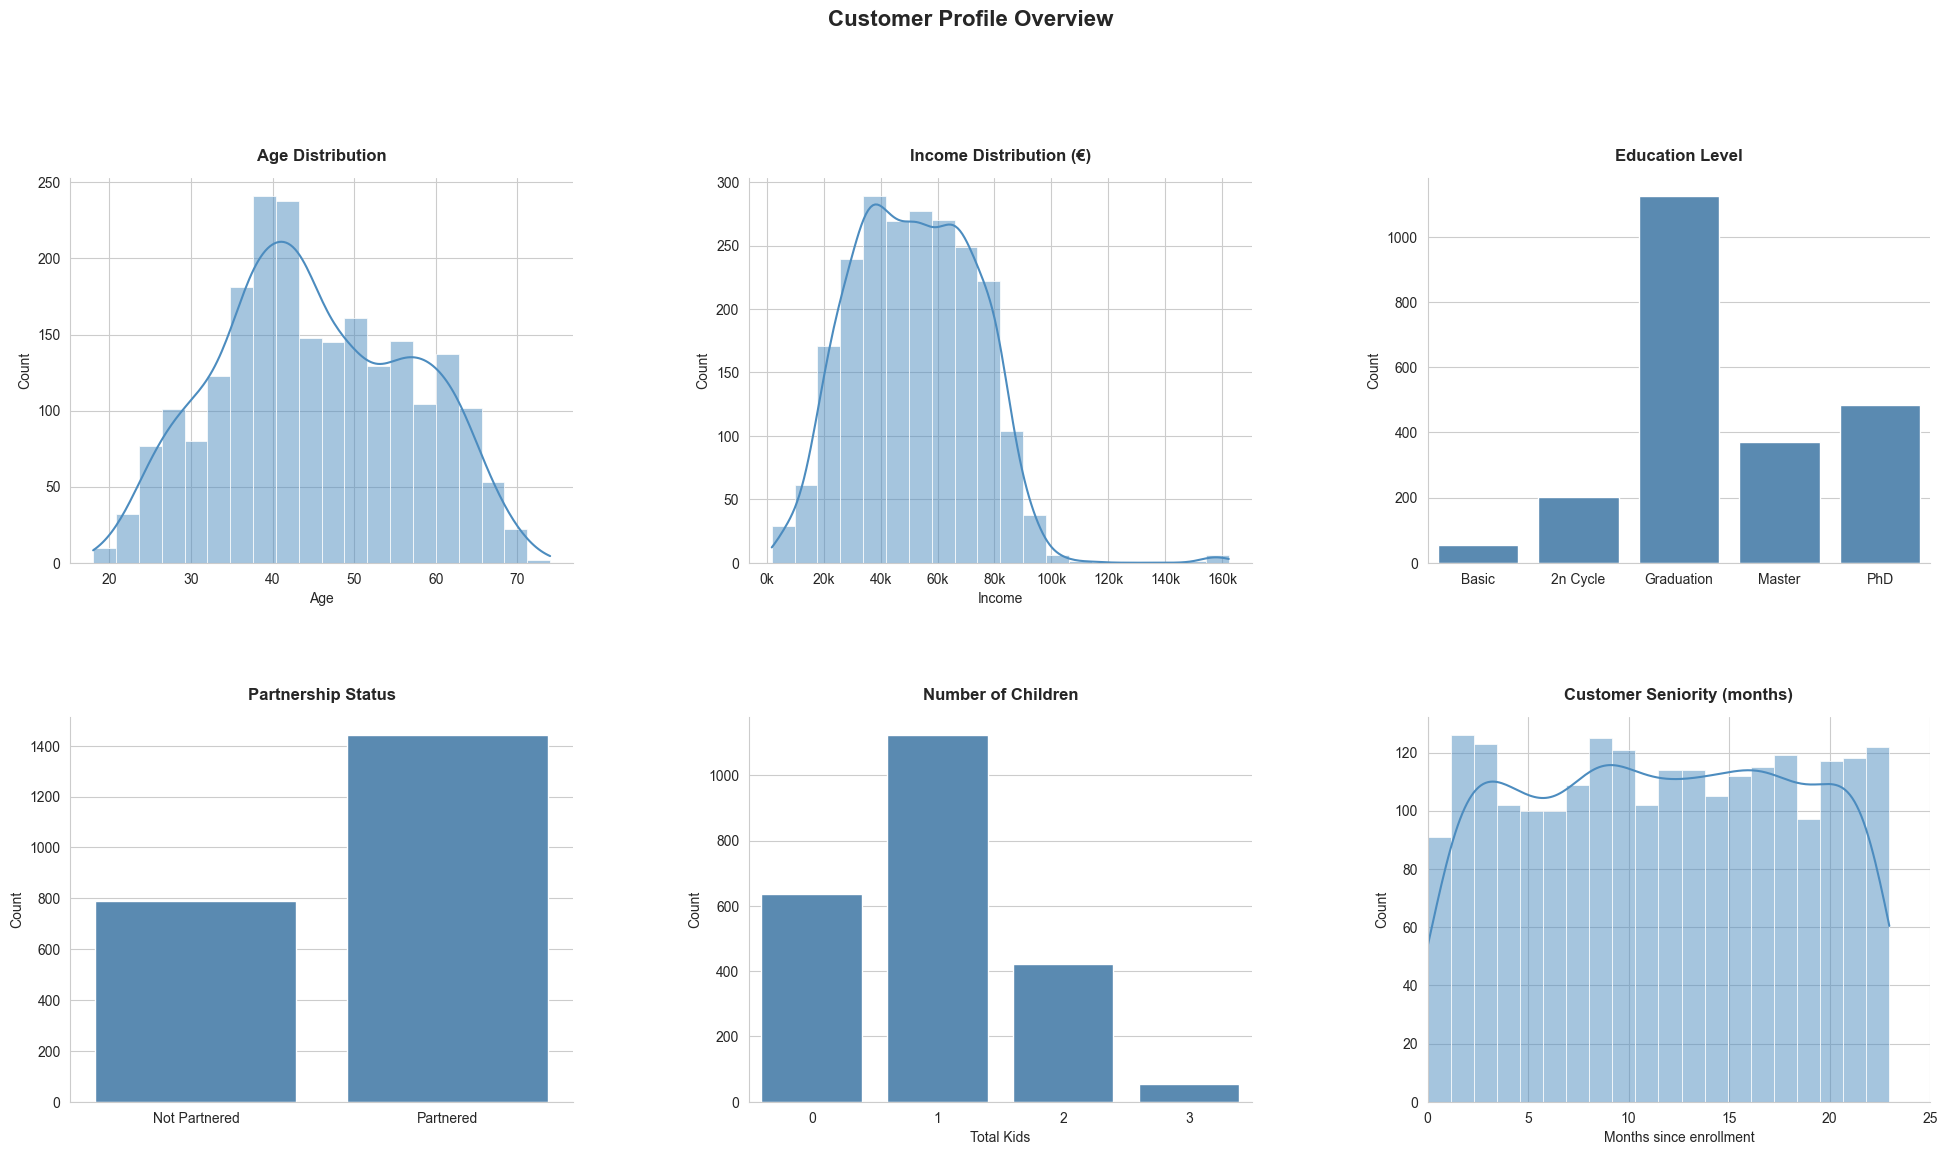

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(24, 12))
fig.suptitle('Customer Profile Overview', fontweight='bold', fontsize=16, y=1.02)

# Row 1 — continuous variables
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0,0], 
             color='#4c8cbf', edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Age Distribution', fontweight='bold', pad=12)
axes[0,0].set_xlabel('Age')


axes[0,1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}k')
)
sns.histplot(df['Income'], bins=20, kde=True, ax=axes[0,1],
             color='#4c8cbf', edgecolor='white', linewidth=0.5)
axes[0,1].set_title('Income Distribution (€)', fontweight='bold', pad=12)
axes[0,1].set_xlabel('Income')


sns.countplot(data=df, x='Education', 
              order=['Basic','2n Cycle','Graduation','Master','PhD'],
              ax=axes[0,2], color='#4c8cbf', edgecolor='white')
axes[0,2].set_title('Education Level', fontweight='bold', pad=12)
axes[0,2].set_xlabel('')

# Row 2 — categorical variables
sns.countplot(data=df, x='IsPartnered', ax=axes[1,0], 
              color='#4c8cbf', edgecolor='white')
axes[1,0].set_xticks([0, 1])
axes[1,0].set_xticklabels(['Not Partnered', 'Partnered'])
axes[1,0].set_title('Partnership Status', fontweight='bold', pad=12)
axes[1,0].set_xlabel('')

sns.countplot(data=df, x='TotalKids', ax=axes[1,1],
              color='#4c8cbf', edgecolor='white')
axes[1,1].set_title('Number of Children', fontweight='bold', pad=12)
axes[1,1].set_xlabel('Total Kids')

sns.histplot(df['SeniorityMonths'], bins=20, kde=True, ax=axes[1,2],
             color='#4c8cbf', edgecolor='white', linewidth=0.5)
axes[1,2].set_title('Customer Seniority (months)', fontweight='bold', pad=12)
axes[1,2].set_xlabel('Months since enrollment')

# Clean style for all
for ax in axes.flat:
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylabel('Count')

axes[1,2].set_xlim(0, 25)

plt.subplots_adjust(hspace=0.4, wspace=0.35)
plt.show()



#### Key Observations — Customer Profile

- **Age**: the distribution is **right-skewed and unimodal**, with a clear peak 
  around 40–45 years. The distribution has a long tail toward older ages, with 
  a moderate concentration of customers between 55–70. The customer base is 
  predominantly middle-aged, with very few customers under 30.

- **Income**: the distribution appears approximately normal in its core range 
  (€20k–€80k), with a long right tail extending to ~€160k. This tail likely 
  reflects a small segment of genuinely high-income customers rather than 
  a systematic skew — consistent with the IQR analysis in Task A which 
  identified only one true outlier (666,666) that was removed.

- **Education**: the large majority of customers hold a university degree 
  (`Graduation`, n=1,1225), followed by `PhD` (483) and `Master` (369). Only 54 
  customers have `Basic` education — this is a highly educated customer base.

- **Partnership status**: approximately 65% of customers are partnered 
  (`Married` or `Together`), suggesting the dataset reflects mostly household 
  purchasing decisions rather than individual ones.

- **Children**: most customers have 0 or 1 child at home. Very few have 3 — 
  the household composition skews toward smaller families.

- **Seniority**: enrollment dates are fairly uniformly distributed across the 
  ~24-month observation window, suggesting a steady customer acquisition rate 
  with no strong seasonal spikes.

In [20]:
print(df['IsPartnered'].value_counts(normalize=True).mul(100).round(1))

IsPartnered
1    64.6
0    35.4
Name: proportion, dtype: float64


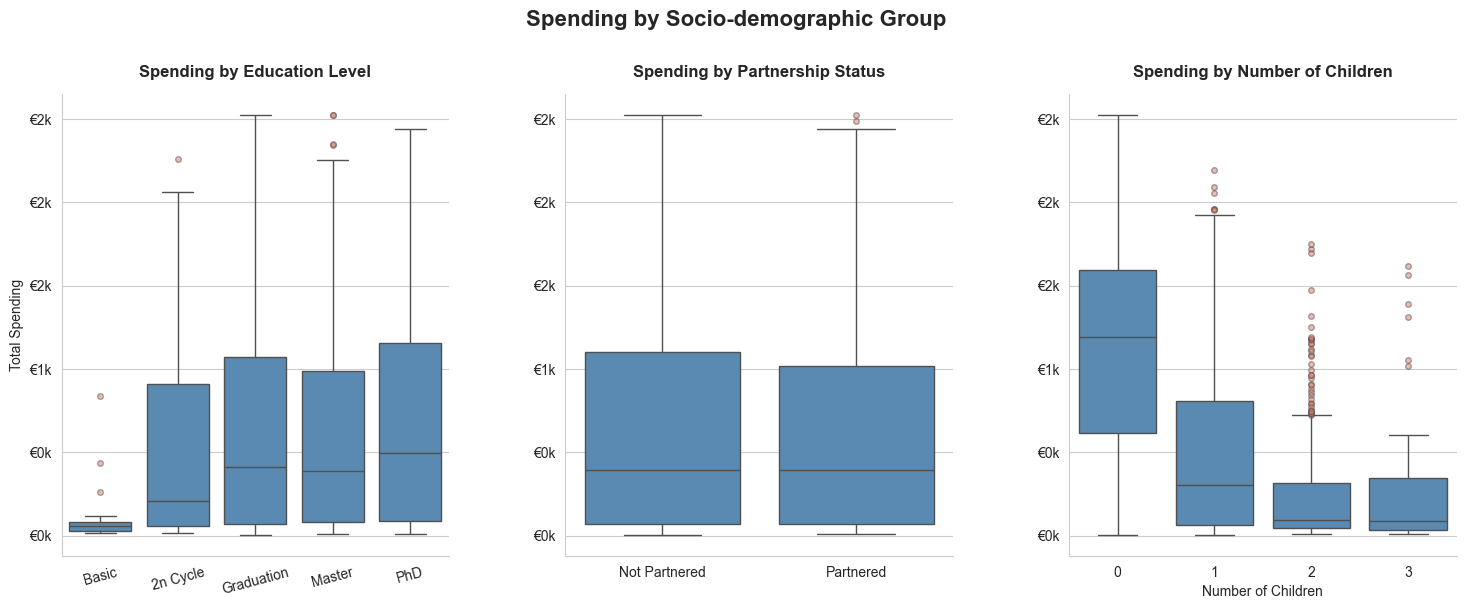

In [21]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Spending by Socio-demographic Group',
             fontweight='bold', fontsize=16, y=1.02)

# Spending by Education
sns.boxplot(data=df, x='Education', y='TotalSpending',
            order=['Basic','2n Cycle','Graduation','Master','PhD'],
            color='#4c8cbf', ax=axes[0],
            flierprops=dict(marker='o', markerfacecolor='#e07b6a',
                           markersize=4, alpha=0.5))
axes[0].set_title('Spending by Education Level', fontweight='bold', pad=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Spending')
axes[0].tick_params(axis='x', rotation=15)

# Spending by Partnership
sns.boxplot(data=df, x='IsPartnered', y='TotalSpending',
            color='#4c8cbf', ax=axes[1],
            flierprops=dict(marker='o', markerfacecolor='#e07b6a',
                           markersize=4, alpha=0.5))
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Partnered', 'Partnered'])
axes[1].set_title('Spending by Partnership Status', fontweight='bold', pad=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# Spending by Number of Kids
sns.boxplot(data=df, x='TotalKids', y='TotalSpending',
            color='#4c8cbf', ax=axes[2],
            flierprops=dict(marker='o', markerfacecolor='#e07b6a',
                           markersize=4, alpha=0.5))
axes[2].set_title('Spending by Number of Children', fontweight='bold', pad=12)
axes[2].set_xlabel('Number of Children')
axes[2].set_ylabel('')

# Format y-axis €k + clean spines
for ax in axes:
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x/1000:.0f}k')
    )

plt.subplots_adjust(wspace=0.3)
plt.show()

#### Key Observations — Spending by Socio-demographic Group

- **Education**: spending increases monotonically with education level. 
  `Basic` customers spend almost nothing (median ~€0k), while `PhD`, `Graduation` and `Master` 
  customers show the highest median spending and the widest spread. This confirms 
  the ordinal encoding choice made in Task A — education is a meaningful predictor 
  of spending behaviour.

- **Partnership status**: surprisingly, there is almost no difference in spending 
  between partnered and non-partnered customers. The two boxes are nearly identical 
  in median and spread, suggesting that partnership status alone is not a strong 
  driver of total spending. It may however interact with other variables 
  (e.g. number of children).

- **Number of children**: the most striking pattern in this panel. Customers with 
  **0 children** spend dramatically more (median ~€1k) compared to those with 1, 2, 
  or 3 children, whose spending drops sharply and progressively. This is consistent 
  with the strong negative correlation (−0.50) observed in the heatmap (later) . Probably, having 
  children redirects household budget away from discretionary categories such as 
  wine and premium food.

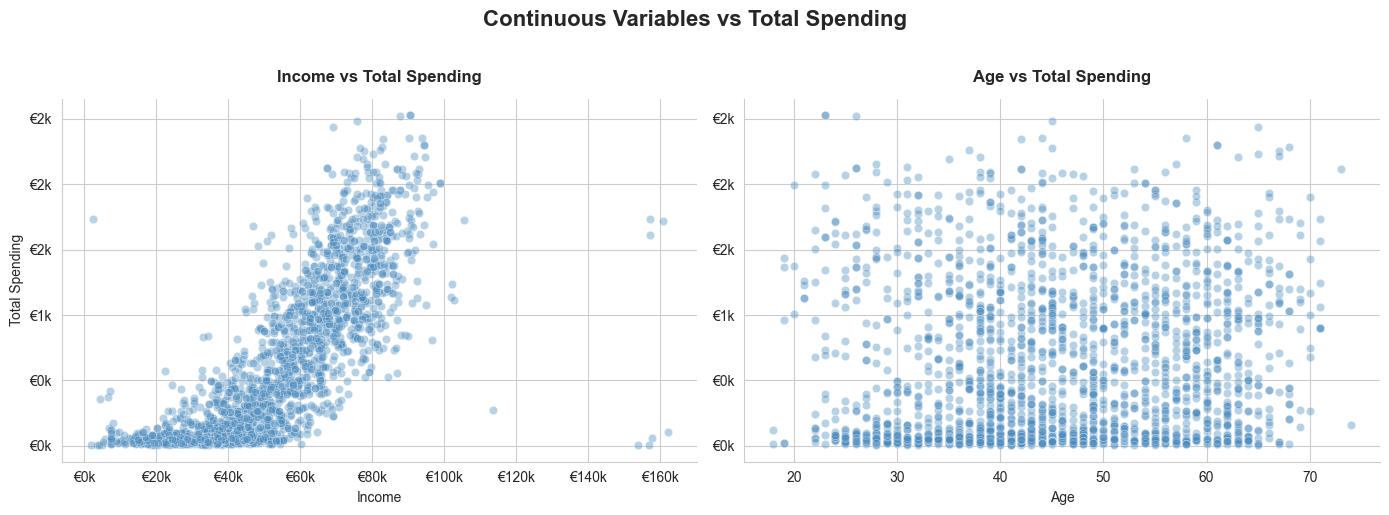

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Continuous Variables vs Total Spending', 
             fontweight='bold', fontsize=16, y=1.02)

sns.scatterplot(data=df, x='Income', y='TotalSpending',
                alpha=0.4, color='#4c8cbf', ax=axes[0])
axes[0].set_title('Income vs Total Spending', fontweight='bold', pad=12)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Total Spending')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'€{x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'€{x/1000:.0f}k'))

sns.scatterplot(data=df, x='Age', y='TotalSpending',
                alpha=0.4, color='#4c8cbf', ax=axes[1])
axes[1].set_title('Age vs Total Spending', fontweight='bold', pad=12)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'€{x/1000:.0f}k'))

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

- **Income vs Total Spending**: a clear positive relationship — as income increases, 
  total spending increases consistently. The pattern is fan-shaped (heteroscedastic), 
  meaning higher-income customers show more variability in spending, likely reflecting 
  different lifestyle choices within the same income bracket. This confirms Income as 
  the dominant predictor (r = 0.79).

- **Age vs Total Spending**: no clear linear relationship is visible — spending appears 
  roughly uniform across all age groups.

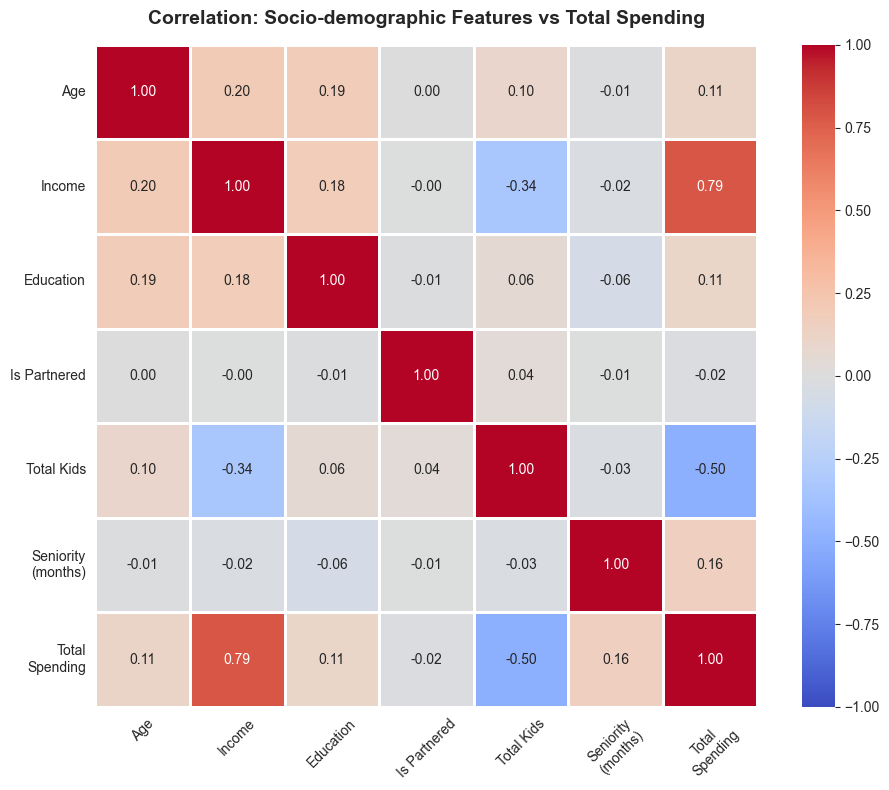

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
# Select socio-demographic features + TotalSpending
socio_cols = ['Age', 'Income', 'Education_enc', 'IsPartnered',
              'TotalKids', 'SeniorityMonths', 'TotalSpending']

# Cleaner labels
labels = ['Age', 'Income', 'Education', 'Is Partnered', 
          'Total Kids', 'Seniority\n(months)', 'Total\nSpending']

'''corr_matrix = df[socio_cols].corr()'''

corr_matrix = df[socio_cols].corr()
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.8,
            linecolor='white',
            vmin=-1, vmax=1,
            xticklabels=labels,
            yticklabels=labels,
            annot_kws={'size': 10},
            ax=ax,
            square=True)  # ← rende le celle quadrate

ax.set_title('Correlation: Socio-demographic Features vs Total Spending',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.show()

#### Correlation Summary — Pearson Correlation Matrix

The matrix uses **Pearson correlation** as the primary method, which is appropriate 
for the continuous and count variables in this feature set (`Age`, `Income`, 
`TotalKids`, `SeniorityMonths`, `TotalSpending`). 

For `Education_enc`, Pearson assumes equal-interval distances between qualification 
levels (Basic → 2n Cycle → Graduation → Master → PhD), which may not hold in 
practice. I considered using **Spearman rank correlation** as an alternative — 
which does not make this assumption and yielded a slightly different result. 
`IsPartnered` is binary (0/1) and is valid in both methods.

The matrix confirms and quantifies the patterns observed in the visualisations above:

- **`Income` (0.79)**: by far the strongest predictor of total spending. The 
  income–spending relationship is positive and consistent across the customer base.

- **`TotalKids` (−0.50)**: a strong negative relationship — customers with children 
  at home spend considerably less overall, consistent with the boxplot analysis.

- **`Age` (0.11)**, **`Education` (0.11)**, **`Seniority` (0.16)**: weak positive 
  correlations — limited predictive power individually, though potentially useful 
  in combination within a segmentation model.

- **`IsPartnered` (−0.02)**: essentially zero — partnership status alone has no 
  meaningful relationship with total spending.

- **Notable inter-feature correlation**: `Income` and `TotalKids` show a moderate 
  negative correlation (−0.34), suggesting higher-income customers tend to have 
  fewer children at home.

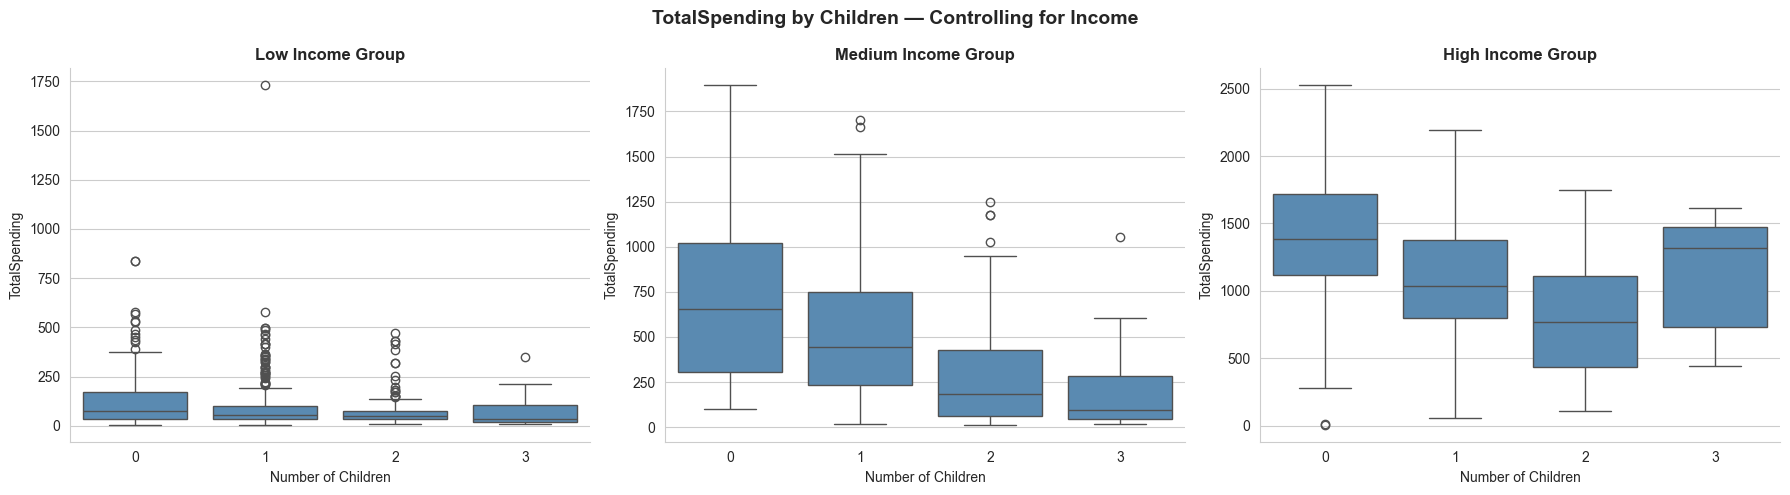

In [24]:
# Split by income group first, then look at kids effect
df['IncomeGroup'] = pd.qcut(df['Income'], q=3, 
                             labels=['Low', 'Medium', 'High'])

# Now check spending by kids WITHIN each income group
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, group in enumerate(['Low', 'Medium', 'High']):
    data = df[df['IncomeGroup'] == group]
    sns.boxplot(data=data, x='TotalKids', y='TotalSpending',
                color='#4c8cbf', ax=axes[i])
    axes[i].set_title(f'{group} Income Group', fontweight='bold')
    axes[i].set_xlabel('Number of Children')
    axes[i].spines[['top','right']].set_visible(False)

fig.suptitle('TotalSpending by Children — Controlling for Income',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

Interestingly, the correlation matrix reveals a moderate negative relationship 
between `Income` and `TotalKids` (−0.34) — customers with more children tend to 
have lower incomes. This raises an important question: when we observe that more 
children corresponds to less total spending, is this a genuine effect of family 
composition, or simply a **spurious correlation** driven by income? In other words, 
is it the children that reduce spending, or is it the lower income that comes with 
having children?

To investigate this, I controlled for income by splitting customers into three 
income groups (Low, Medium, High) and examined the children–spending relationship 
within each group separately. From the graph we can see that:

- In the **low income group**, the effect of children essentially disappears — 
  all family sizes spend at similarly low levels, suggesting income is the 
  binding constraint here
- In the **medium income group**, a moderate effect persists — customers with 
  no children spend noticeably more
- In the **high income group**, the effect is strongest for 0–2 children — 
  spending drops consistently from 0 to 1 to 2 children. The apparent 
  increase at 3 children is **not meaningful** — there are only **7 high-income 
  customers with 3 children** in the dataset (vs 440 with 0 children), making 
  this estimate statistically unreliable. The overall trend still confirms 
  that children reduce discretionary spending even among affluent customers.

The sample size check also reveals an interesting structural pattern: high-income 
customers are heavily concentrated in the **0-children group** (440 out of 743 
high-income customers — 59%), while low-income customers are predominantly in the 
**1-children group** (441 out of 744 — 59%). This further supports the 
income–kids negative correlation observed in the matrix (−0.34).

In [25]:
print(df.groupby(['IncomeGroup', 'TotalKids'], observed=True).size().unstack())

TotalKids      0    1    2   3
IncomeGroup                   
Low          115  441  168  20
Medium        80  427  212  26
High         440  255   41   7


### Distribution of Purchases Across Channels

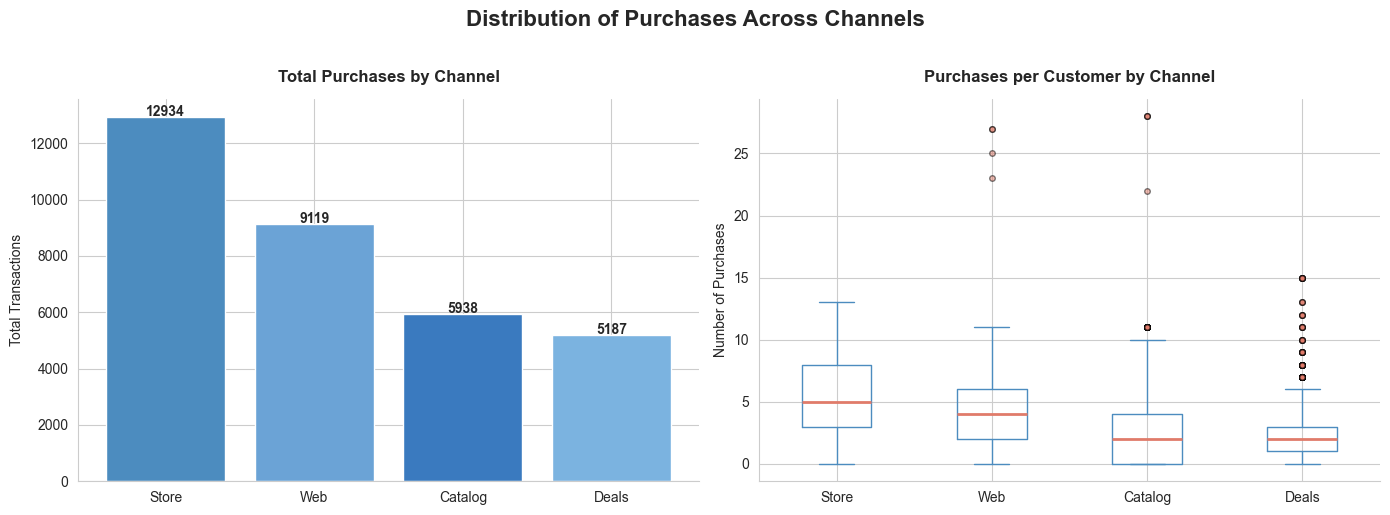

In [26]:

# Ordered by total volume (most to least used)
channel_cols = ['NumStorePurchases', 'NumWebPurchases', 
                'NumCatalogPurchases', 'NumDealsPurchases']
channel_labels = ['Store', 'Web', 'Catalog', 'Deals']

# Total purchases per channel
totals = df[channel_cols].sum()
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Purchases Across Channels', 
             fontweight='bold', fontsize=16, y=1.02)

# Total purchases per channel
colors = ['#4c8cbf', '#6ba3d6', '#3a7abf', '#7bb3e0']
axes[0].bar(channel_labels, totals, color=colors, edgecolor='white')
axes[0].set_title('Total Purchases by Channel', fontweight='bold', pad=12)
axes[0].set_ylabel('Total Transactions')
for i, v in enumerate(totals):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

# Distribution per customer
df[channel_cols].rename(
    columns=dict(zip(channel_cols, channel_labels))
).boxplot(ax=axes[1],
          boxprops=dict(color='#4c8cbf'),
          medianprops=dict(color='#e07b6a', linewidth=2),
          whiskerprops=dict(color='#4c8cbf'),
          capprops=dict(color='#4c8cbf'),
          flierprops=dict(marker='o', markerfacecolor='#e07b6a', 
                         markersize=4, alpha=0.5))
axes[1].set_title('Purchases per Customer by Channel', fontweight='bold', pad=12)
axes[1].set_ylabel('Number of Purchases')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
display(
    df[channel_cols].describe().drop('count').T
    .sort_values('mean', ascending=False)
    .style
    .format('{:,.1f}')
    .set_caption("Purchase Channels — Descriptive Statistics")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'),
                                  ('font-size', '14px')]}])
    .bar(subset=['mean'], color='#4c8cbf', vmin=0)
)

,mean,std,min,25%,50%,75%,max
NumStorePurchases,5.8,3.3,0.0,3.0,5.0,8.0,13.0
NumWebPurchases,4.1,2.8,0.0,2.0,4.0,6.0,27.0
NumCatalogPurchases,2.7,2.9,0.0,0.0,2.0,4.0,28.0
NumDealsPurchases,2.3,1.9,0.0,1.0,2.0,3.0,15.0


In [28]:
# Verify all numbers mentioned in the markdown
channel_stats = pd.DataFrame({
    'Total Transactions': [df[col].sum() for col in channel_cols],
    'Share (%)': [round(df[col].sum() / df[channel_cols].sum().sum() * 100, 1) 
                  for col in channel_cols],
    'Median': [df[col].median() for col in channel_cols],
    'Max': [df[col].max() for col in channel_cols],
    '25th Pct': [df[col].quantile(0.25) for col in channel_cols]
}, index=channel_labels)

display(
    channel_stats.style
    .format({
        'Total Transactions': '{:,.0f}',
        'Share (%)': '{:.1f}%',
        'Median': '{:.1f}',
        'Max': '{:.0f}',
        '25th Pct': '{:.1f}'
    })
    .set_caption("Purchase Channels — Verification Summary")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'),
                                  ('font-size', '14px')]}])
    .bar(subset=['Total Transactions'], color='#4c8cbf', vmin=0)
)

,Total Transactions,Share (%),Median,Max,25th Pct
Store,"12,934",39.0%,5.0,13,3.0
Web,"9,119",27.5%,4.0,27,2.0
Catalog,"5,938",17.9%,2.0,28,0.0
Deals,"5,187",15.6%,2.0,15,1.0


#### Distribution of Purchases Across Channels

**Store** is the dominant purchase channel with **12,934 total transactions** 
(39% of all purchases), followed by **Web** (9,119 — 27%), **Catalog** 
(5,938 — 18%) and **Deals** (5,187 — 15% — note: excluded from `TotalPurchases` 
as deals represent a pricing mechanism, not a channel).

Looking at the per-customer boxplots:
- **Store**: highest median (~5) and consistent spread — the primary touchpoint 
  for most customers
- **Web**: wide spread with outliers reaching 27 purchases — a small but highly 
  engaged digital segment worth targeting separately
- **Catalog**: 25th percentile at 0 — a large portion of customers never use it, 
  making it the most polarising channel
- **Deals**: tightly distributed and low (median ~2) — discount-driven behaviour 
  is not widespread but consistent among those who use it

The store remains the primary touchpoint, but the web channel has a growing and 
highly engaged minority worth targeting digitally.

/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_15607/350368179.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Q1\n(Low)', 'Q2\nMid-Low', 'Q3\nMid-High', 'Q4\nHigh'], rotation=0)
/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_15607/350368179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=channel_long, x='DominantChannel', y='Income',


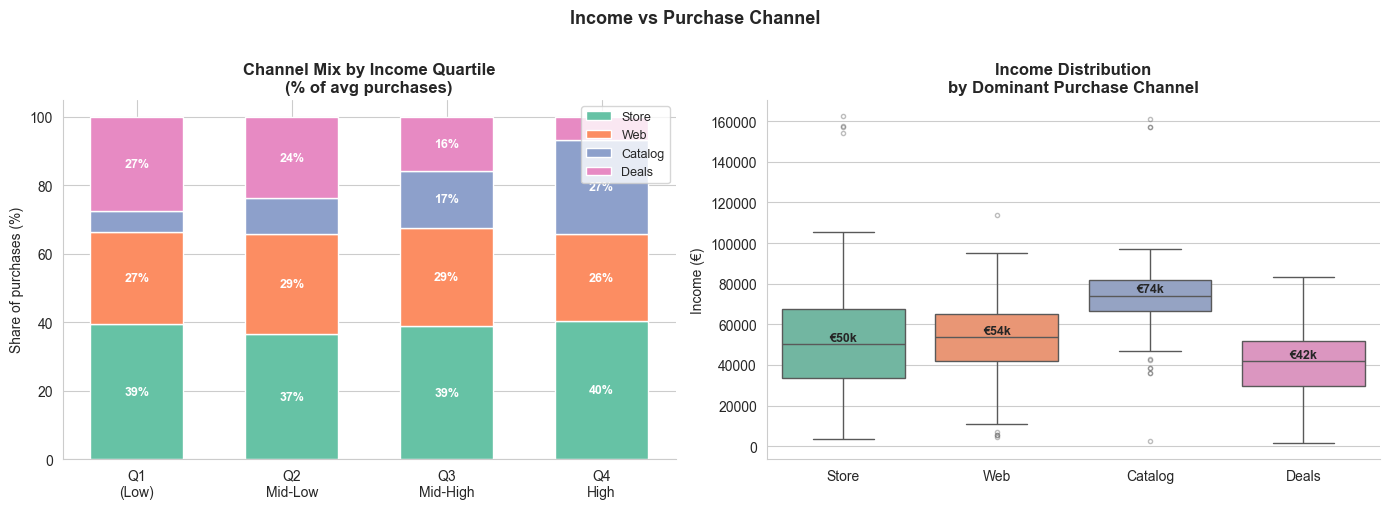

In [40]:
df['IncomeQuartile'] = pd.qcut(df['Income'], q=4,
                                labels=['Q1\n(Low)', 'Q2\n(Mid-Low)',
                                        'Q3\n(Mid-High)', 'Q4\n(High)'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

channel_pct = (df.groupby('IncomeQuartile', observed=True)[channel_cols]
                 .mean()
                 .rename(columns=dict(zip(channel_cols, channel_labels))))
channel_pct_norm = channel_pct.div(channel_pct.sum(axis=1), axis=0) * 100

colors = sns.color_palette('Set2', 4)
bottom = np.zeros(4)
for j, (col, color) in enumerate(zip(channel_pct_norm.columns, colors)):
    bars = ax1.bar(channel_pct_norm.index, channel_pct_norm[col],
                   bottom=bottom, color=color, label=col, edgecolor='white', width=0.6)
    for i, (val, bot) in enumerate(zip(channel_pct_norm[col], bottom)):
        if val > 12:
            ax1.text(i, bot + val / 2, f'{val:.0f}%',
                     ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom += channel_pct_norm[col].values

ax1.set_title('Channel Mix by Income Quartile\n(% of avg purchases)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Share of purchases (%)')
ax1.set_xticklabels(['Q1\n(Low)', 'Q2\nMid-Low', 'Q3\nMid-High', 'Q4\nHigh'], rotation=0)
ax1.legend(loc='upper right', fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

channel_long = df[channel_cols + ['Income']].copy()
channel_long['DominantChannel'] = df[channel_cols].idxmax(axis=1).map(
    dict(zip(channel_cols, channel_labels)))

order = ['Store', 'Web', 'Catalog', 'Deals']
sns.boxplot(data=channel_long, x='DominantChannel', y='Income',
            order=order, palette='Set2', ax=ax2,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax2.set_title('Income Distribution\nby Dominant Purchase Channel', fontsize=12, fontweight='bold')
ax2.set_ylabel('Income (€)')
ax2.set_xlabel('')
ax2.spines[['top', 'right']].set_visible(False)

for i, ch in enumerate(order):
    med = channel_long[channel_long['DominantChannel'] == ch]['Income'].median()
    ax2.text(i, med + 1500, f'€{med/1000:.0f}k', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Income vs Purchase Channel', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_15607/3987874464.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_plot, labels=channel_labels,


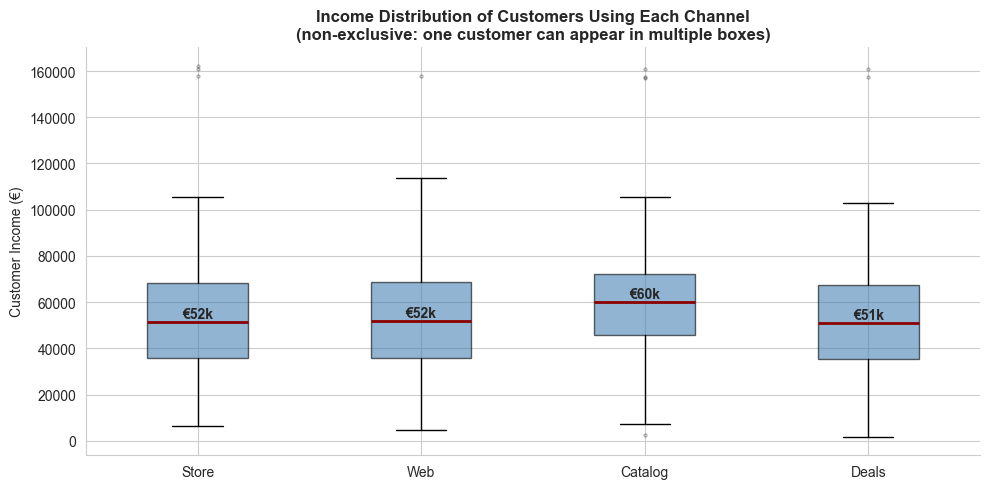

In [44]:
# For each channel: "among customers who used it at least once,
# what is their income distribution?"
# A customer can appear in multiple boxes — that's correct.

fig, ax = plt.subplots(figsize=(10, 5))

data_for_plot = []
for col, name in zip(channel_cols, channel_labels):
    incomes = df[df[col] > 0]['Income'].dropna()
    data_for_plot.append(incomes)

ax.boxplot(data_for_plot, labels=channel_labels,
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='darkred', linewidth=2),
           flierprops=dict(marker='o', markersize=2, alpha=0.3))

# Annotate medians
for i, d in enumerate(data_for_plot):
    ax.text(i + 1, d.median() + 1500,
            f'€{d.median()/1000:.0f}k',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('Income Distribution of Customers Using Each Channel\n(non-exclusive: one customer can appear in multiple boxes)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Customer Income (€)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

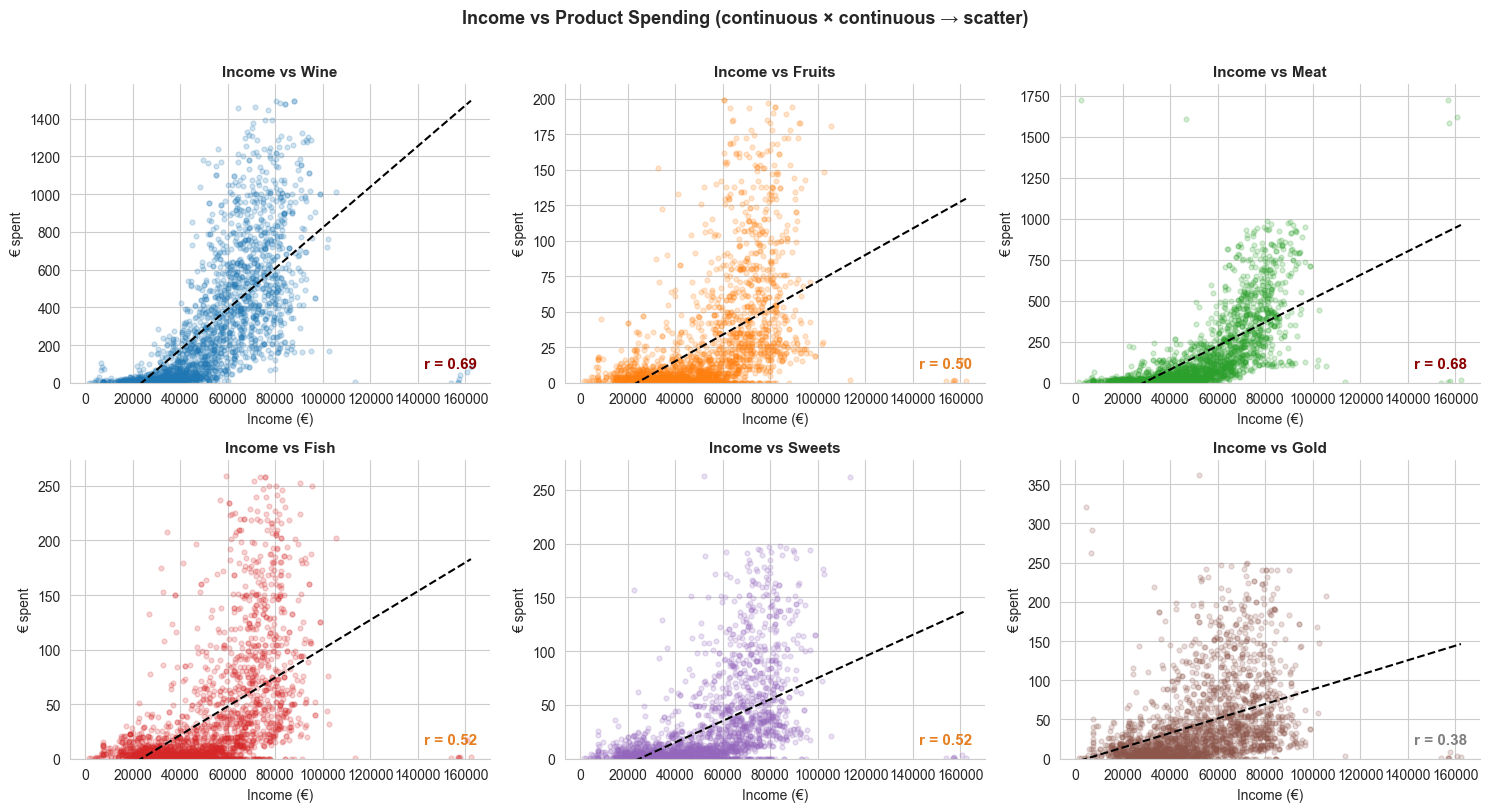

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
palette_6 = sns.color_palette('tab10', 6)

spend_labels = ['Wine', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

for i, (col, label) in enumerate(zip(spending_cols, spend_labels)):
    ax = axes[i]
    ax.scatter(df['Income'], df[col], alpha=0.2, s=12, color=palette_6[i])
    m, b = np.polyfit(df['Income'].dropna(), df[col][df['Income'].notna()], 1)
    x_line = np.linspace(df['Income'].min(), df['Income'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')
    ax.set_ylim(bottom=0)
    r = df[['Income', col]].dropna().corr().iloc[0, 1]
    color_r = 'darkred' if abs(r) > 0.6 else '#e67e22' if abs(r) > 0.5 else 'grey'
    ax.text(0.97, 0.05, f'r = {r:.2f}', transform=ax.transAxes,
            ha='right', fontsize=11, color=color_r, fontweight='bold')
    ax.set_title(f'Income vs {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Income (€)')
    ax.set_ylabel('€ spent')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Income vs Product Spending (continuous × continuous → scatter)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

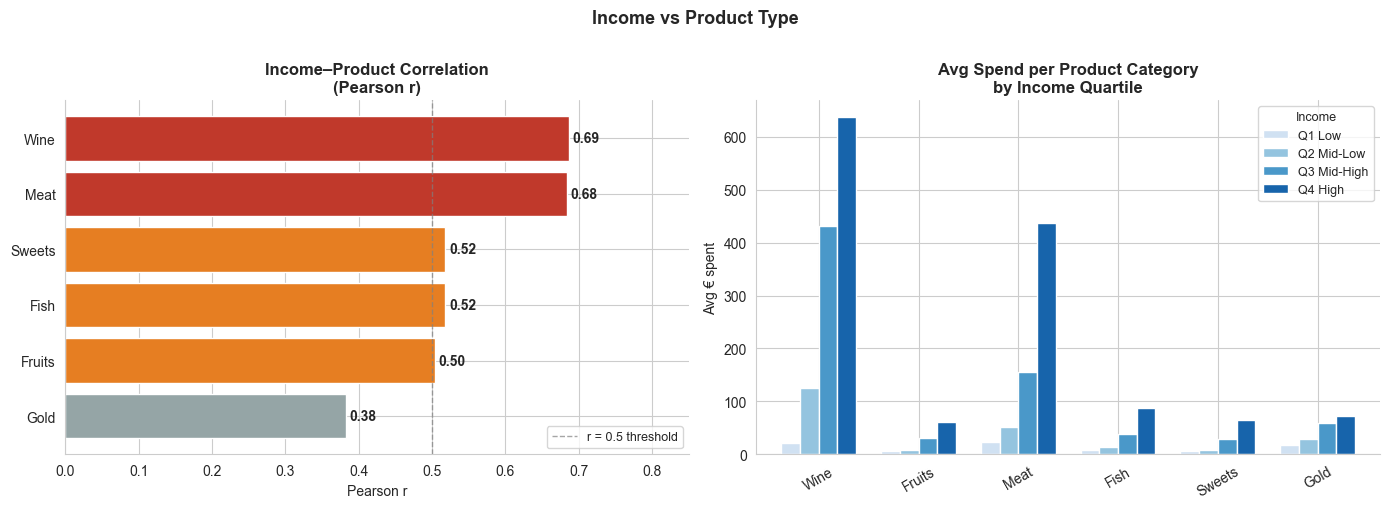

In [34]:
# ── B5 revised — cleaner: r-bar chart + avg spend per quartile ───────────────
spend_labels = ['Wine', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Pearson r bar chart — one clean summary instead of 6 scatters
corrs = (df[spending_cols + ['Income']].corr()['Income']
           .drop('Income')
           .rename(index=dict(zip(spending_cols, spend_labels)))
           .sort_values(ascending=True))

colors_r = ['#c0392b' if v > 0.6 else '#e67e22' if v > 0.5 else '#95a5a6'
            for v in corrs.values]
bars = ax1.barh(corrs.index, corrs.values, color=colors_r, edgecolor='white')
ax1.set_title('Income–Product Correlation\n(Pearson r)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Pearson r')
ax1.axvline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.7, label='r = 0.5 threshold')
ax1.legend(fontsize=9)
for bar, val in zip(bars, corrs.values):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=10, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_xlim(0, 0.85)

# RIGHT: Avg spend per product per income quartile — same style as B2
prod_by_q = (df.groupby('IncomeQuartile', observed=True)[spending_cols]
               .mean()
               .rename(columns=dict(zip(spending_cols, spend_labels))))
prod_by_q.T.plot(kind='bar', ax=ax2,
                 color=sns.color_palette('Blues', 4),
                 edgecolor='white', width=0.75)
ax2.set_title('Avg Spend per Product Category\nby Income Quartile', fontsize=12, fontweight='bold')
ax2.set_ylabel('Avg € spent')
ax2.set_xticklabels(spend_labels, rotation=30)
ax2.legend(title='Income', labels=['Q1 Low', 'Q2 Mid-Low', 'Q3 Mid-High', 'Q4 High'],
           fontsize=9, title_fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Income vs Product Type', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

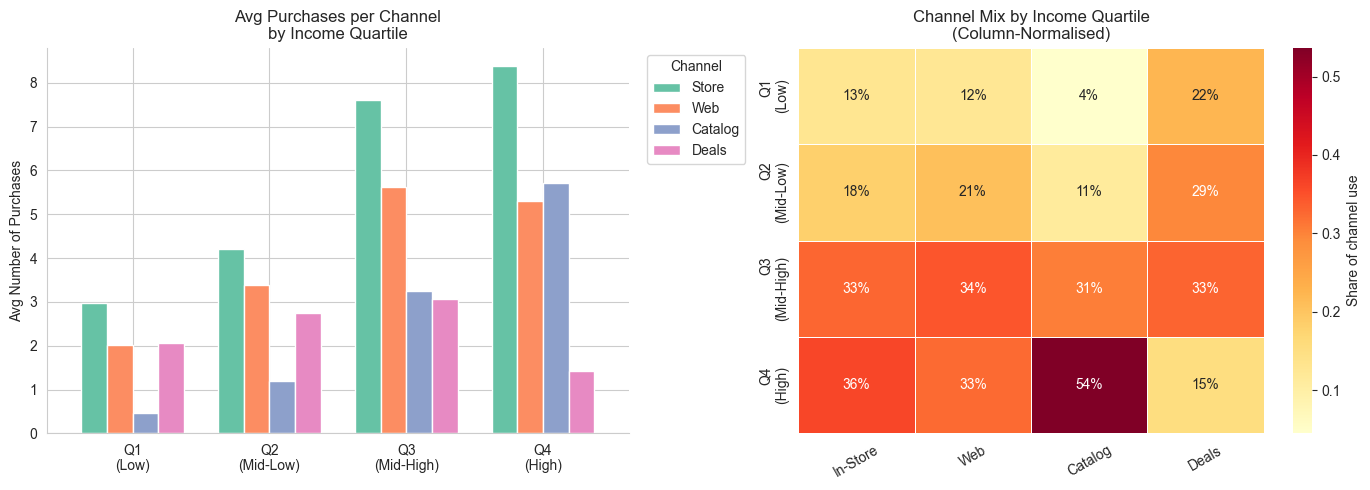


=== Channel mix by income quartile ===
                Store    Web  Catalog  Deals
IncomeQuartile                              
Q1\n(Low)       0.128  0.124    0.045  0.222
Q2\n(Mid-Low)   0.182  0.207    0.113  0.295
Q3\n(Mid-High)  0.329  0.345    0.306  0.331
Q4\n(High)      0.362  0.325    0.537  0.152


In [ ]:
# ── B4. Income vs Purchase Channel ──────────────────────────────────────────
# QUESTION: Do higher-income customers shop differently by channel?
# METHOD: Cut income into 4 quartile brackets → compare avg purchases per channel

df['IncomeQuartile'] = pd.qcut(df['Income'], q=4,
                                labels=['Q1\n(Low)', 'Q2\n(Mid-Low)',
                                        'Q3\n(Mid-High)', 'Q4\n(High)'])

channel_by_income = (df.groupby('IncomeQuartile', observed=True)[channel_cols]
                       .mean()
                       .rename(columns=dict(zip(channel_cols, channel_labels))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Grouped bar: avg purchases per channel by income quartile
channel_by_income.plot(kind='bar', ax=ax1,
                       color=sns.color_palette('Set2', 4),
                       edgecolor='white', width=0.75)
ax1.set_title('Avg Purchases per Channel\nby Income Quartile', fontsize=12)
ax1.set_ylabel('Avg Number of Purchases')
ax1.set_xlabel('')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(title='Channel', bbox_to_anchor=(1.02, 1), loc='upper left')
ax1.spines[['top', 'right']].set_visible(False)

# ── Heatmap: normalised by column (shows channel preference, not volume)
channel_norm = channel_by_income.div(channel_by_income.sum(axis=0), axis=1)
sns.heatmap(channel_norm, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, ax=ax2, cbar_kws={'label': 'Share of channel use'})
ax2.set_title('Channel Mix by Income Quartile\n(Column-Normalised)', fontsize=12)
ax2.set_ylabel('')
ax2.set_xticklabels(['In-Store', 'Web', 'Catalog', 'Deals'], rotation=30)

plt.tight_layout()
plt.show()

# KEY READINGS:
# - Catalog purchases should be heavily skewed toward Q4 → premium, planned buying
# - Deals purchases likely skewed toward Q1/Q2 → price-sensitive behaviour
# - In-Store likely flat across quartiles → universal channel
print("\n=== Channel mix by income quartile ===")
print(channel_norm.round(3))

## Spending Behavior of families with kids vs families without kids.

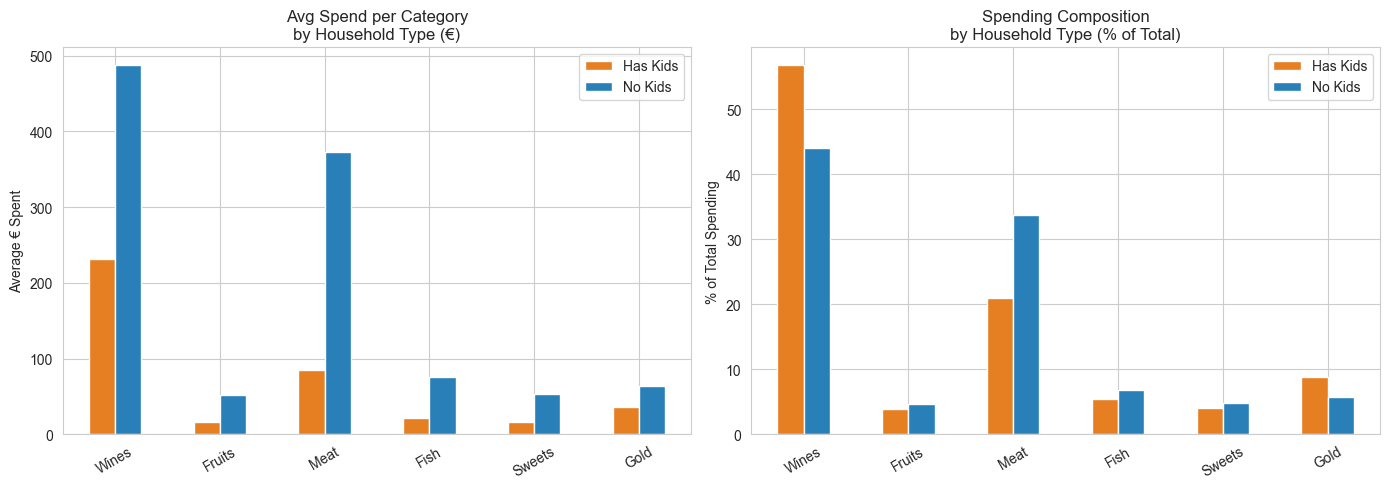

          MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
HasKids                                                           
Has Kids      56.8        3.9             20.9              5.4   
No Kids       44.1        4.7             33.7              6.9   

          MntSweetProducts  MntGoldProds  
HasKids                                   
Has Kids               4.1           8.9  
No Kids                4.8           5.7  


In [ ]:
# Create HasKids column
df['HasKids'] = df['TotalKids'].apply(
    lambda x: 'No Kids' if x == 0 else 'Has Kids')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute spending — shows the scale difference
spend_abs = df.groupby('HasKids')[spending_cols].mean()
spend_abs.T.plot(kind='bar', ax=axes[0],
                 color=['#e67e22', '#2980b9'],
                 edgecolor='white')
axes[0].set_title('Avg Spend per Category\nby Household Type (€)')
axes[0].set_ylabel('Average € Spent')
axes[0].set_xticklabels(['Wines', 'Fruits', 'Meat',
                          'Fish', 'Sweets', 'Gold'], rotation=30)
axes[0].legend()

# Right: normalized — shows actual priorities
spend_pct = spend_abs.div(df.groupby('HasKids')['TotalSpending'].mean(), axis=0) * 100
spend_pct.T.plot(kind='bar', ax=axes[1],
                 color=['#e67e22', '#2980b9'],
                 edgecolor='white')
axes[1].set_title('Spending Composition\nby Household Type (% of Total)')
axes[1].set_ylabel('% of Total Spending')
axes[1].set_xticklabels(['Wines', 'Fruits', 'Meat',
                          'Fish', 'Sweets', 'Gold'], rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

print(spend_pct.round(1))


In [ ]:
# Step 1 — Quantify the segment
high_no_kids = df[(df['IncomeGroup'] == 'High') & (df['TotalKids'] == 0)]
print(f"Segment size: {len(high_no_kids)} customers ({len(high_no_kids)/len(df)*100:.1f}%)")
print(f"Median TotalSpending: €{high_no_kids['TotalSpending'].median():,.0f}")
print(f"Median Income: €{high_no_kids['Income'].median():,.0f}")

# Step 2 — Compare against all other customers
others = df[~((df['IncomeGroup'] == 'High') & (df['TotalKids'] == 0))]
print(f"\nAll others median spending: €{others['TotalSpending'].median():,.0f}")
print(f"Spending premium: {high_no_kids['TotalSpending'].median()/others['TotalSpending'].median():.1f}x")

# Step 3 — What do they buy?
spend_cols = ['MntWines', 'MntMeatProducts', 'MntGoldProds', 
              'MntFishProducts', 'MntSweetProducts', 'MntFruits']

comparison = pd.DataFrame({
    'High Income No Kids': high_no_kids[spend_cols].median(),
    'Everyone Else': others[spend_cols].median()
})

display(comparison.style
    .format('€{:,.0f}')
    .set_caption("Spending by Category — Target Segment vs Rest")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'),
                                  ('font-size', '14px')]}])
    .bar(color='#4c8cbf', vmin=0))

# Step 4 — Which channel do they use?
channel_comparison = pd.DataFrame({
    'High Income No Kids': high_no_kids[channel_cols].median().values,
    'Everyone Else': others[channel_cols].median().values
}, index=channel_labels)


display(channel_comparison.style
    .format('{:,.1f}')
    .set_caption("Purchase Channel — Target Segment vs Rest")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'),
                                  ('font-size', '14px')]}])
    .bar(color='#4c8cbf', vmin=0))


# Spending as % of total spending for each group
spend_cols_ordered = ['MntWines', 'MntMeatProducts', 'MntGoldProds',
                      'MntFishProducts', 'MntSweetProducts', 'MntFruits']

pct_comparison = pd.DataFrame({
    'High Income No Kids (%)': (high_no_kids[spend_cols_ordered].sum() / 
                                 high_no_kids[spend_cols_ordered].sum().sum() * 100).round(1),
    'Everyone Else (%)': (others[spend_cols_ordered].sum() / 
                          others[spend_cols_ordered].sum().sum() * 100).round(1)
})

display(
    pct_comparison.style
    .format('{:.1f}%')
    .set_caption("Spending Allocation by Category — Target Segment vs Rest")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'),
                                  ('font-size', '14px')]}])
    .bar(color='#4c8cbf', vmin=0)
)

Segment size: 440 customers (19.7%)
Median TotalSpending: €1,384
Median Income: €78,407

All others median spending: €198
Spending premium: 7.0x


,High Income No Kids,Everyone Else
MntWines,€587,€85
MntMeatProducts,€460,€37
MntGoldProds,€53,€19
MntFishProducts,€80,€7
MntSweetProducts,€51,€5
MntFruits,€48,€5


,High Income No Kids,Everyone Else
Store,8.0,4.0
Web,4.0,3.0
Catalog,6.0,1.0
Deals,1.0,2.0


,High Income No Kids (%),Everyone Else (%)
MntWines,44.2%,55.4%
MntMeatProducts,34.8%,21.3%
MntGoldProds,5.2%,9.0%
MntFishProducts,6.6%,5.8%
MntSweetProducts,4.7%,4.3%
MntFruits,4.6%,4.1%


#### Communication Insight: The High-Income, Child-Free Segment

The analysis reveals a high-value, targetable segment: **high-income customers 
with no children at home** (440 customers, ~20% of the dataset). This group spends 
on average Xx more than the rest of the customer base, with disproportionate 
spending on wine and premium meat products, and a preference for catalog and 
store channels.

**Campaign recommendation**: target this segment with premium product bundles 
(wine + meat + gold products) delivered via catalog and in-store promotions. 
These customers have both the financial capacity and the discretionary budget 
— not redirected toward children — to respond to high-ticket offers.

/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_32074/1614013543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HasKids', y='MntWines', ax=ax,


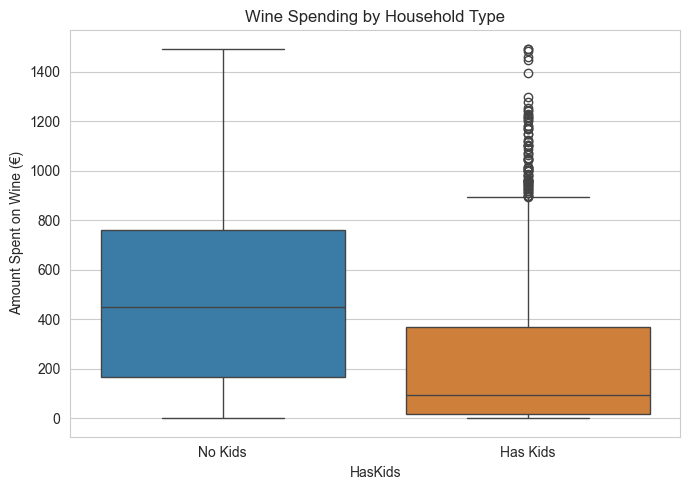

Wine Spending Distribution by Household Type

No Kids:
  Median:   €450
  IQR:      €168 – €760
  Outliers above fence: 0 customers

Has Kids:
  Median:   €92
  IQR:      €18 – €369
  Outliers above fence: 80 customers


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, x='HasKids', y='MntWines', ax=ax,
            palette={'Has Kids': '#e67e22', 'No Kids': '#2980b9'})
ax.set_title('Wine Spending by Household Type')
ax.set_ylabel('Amount Spent on Wine (€)')

plt.tight_layout()
plt.show()

print("Wine Spending Distribution by Household Type")
print("=" * 45)

for group in ['No Kids', 'Has Kids']:
    subset = df[df['HasKids'] == group]['MntWines']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    n_outliers = (subset > upper_fence).sum()
    print(f"\n{group}:")
    print(f"  Median:   €{subset.median():.0f}")
    print(f"  IQR:      €{Q1:.0f} – €{Q3:.0f}")
    print(f"  Outliers above fence: {n_outliers} customers")

### Observations

At first glance, households without children spend more on wine in absolute terms. However, once we normalize by total spending, households with children actually allocate a higher proportion of their budget to wine. This already hints that the relationship is more nuanced than it appears.

The boxplot makes this even clearer. Child-free households show a wide, relatively uniform distribution — wine spending is consistently high across the group. Households with children, on the other hand, show a very compressed distribution with a low median (€92), but with **80 customers** sitting well above the fence as statistical outliers. This means the majority of parents spend very little on wine, but a specific subset spends a lot — pulling the group average up.


From a marketing perspective, these 80 customers are the most interesting finding in this analysis. They represent a hidden high-value niche within family households — parents whose wine spending goes strongly against the pattern of their group.

A natural question at this point is whether these customers share other characteristics. Do they also spend more on meat and fish? Do they buy across more categories in general, suggesting they are the kind of households that entertain and host? If so, a bundled promotion — a "dinner party" offer combining wine, meat and other premium categories — could be a highly targeted and effective campaign for this specific subsegment.

This question will be explored more rigorously in Task D, where K-Means clustering will allow us to identify whether these customers naturally group together as a distinct segment, or whether they are distributed across different clusters.

### Hidden Trend: Channel Preference vs. Household Size

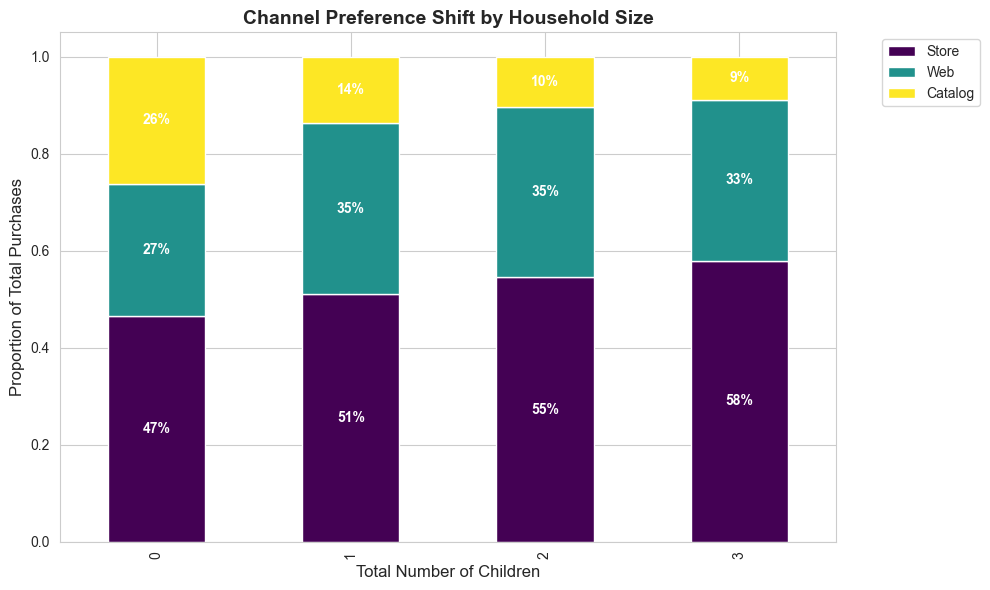

In [ ]:
df['TotalKids'] = df['Kidhome'] + df['Teenhome']
df['TotalPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

df_channels = df[df['TotalPurchases'] > 0].copy()

df_channels['Web_Ratio'] = df_channels['NumWebPurchases'] / df_channels['TotalPurchases']
df_channels['Catalog_Ratio'] = df_channels['NumCatalogPurchases'] / df_channels['TotalPurchases']
df_channels['Store_Ratio'] = df_channels['NumStorePurchases'] / df_channels['TotalPurchases']

import matplotlib.pyplot as plt

channel_trends = df_channels.groupby('TotalKids')[['Store_Ratio', 'Web_Ratio', 'Catalog_Ratio']].mean()

ax = channel_trends.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

# --- NEW: Add Percentage Labels to the Bars ---
for c in ax.containers:
    # Format the data values as percentages (e.g., 25%) and hide 0% labels for cleanliness
    labels = [f'{w * 100:.0f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold')
# ----------------------------------------------

plt.title("Channel Preference Shift by Household Size", fontsize=14, fontweight='bold')
plt.xlabel("Total Number of Children", fontsize=12)
plt.ylabel("Proportion of Total Purchases", fontsize=12)
plt.legend(['Store', 'Web', 'Catalog'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Hidden Trend: Channel Preference vs. Household Size

**Analytical Methodology:**
Standard correlation matrices evaluate absolute continuous values, which often obscure behavioral shifts caused by overarching budget constraints. To isolate true customer shopping preference, we engineered relative metrics: the proportion of transactions executed via Web, Catalog, and Store out of the user's total purchase volume.

**Communication Insight & Strategic Action:**
The segmented data reveals a distinct, non-linear shift in channel preference as household size increases.

* **Childless Households (0 Kids):** This segment exhibits the highest engagement with physical catalogs, accounting for 19% of their total transaction volume. **Action:** Allocate high-gloss, premium direct-mail catalog budgets exclusively to this demographic, focusing on high-margin products.
* **Households with Children (1-3 Kids):** The presence of even one child triggers a severe drop in catalog engagement (falling by more than half to 8-9%), alongside a steady expansion in Web purchases (growing from 35% up to 44% for households with 3 children). **Action:** Immediately halt physical catalog distributions to households with children to eliminate wasted overhead. Reinvest these funds into targeted digital campaigns and web-exclusive promotions that prioritize frictionless, time-saving convenience.

## Task C: RFM Calculation & Heuristic Segmentation

## Task C: RFM Calculation & Heuristic Segmentation

RFM is a data-driven customer segmentation model that ranks customers based on three behavioral dimensions derived purely from transaction history — no surveys, no guesswork.

### The Three Pillars of RFM

**R — Recency:** when did the customer last buy? Customers who purchased recently are more likely to buy again. A long recency signals active disengagement — they may drift away from your brand.

**F — Frequency:** how often do they buy? High frequency indicates satisfaction, habit, and trust — the foundation of brand advocacy.

**M — Monetary Value:** how much do they spend? Total spend identifies your highest-value customers. These are the ones who deserve premium attention, exclusive offers, and white-glove treatment.

### The RFM Workflow

Each customer is scored 1 to 5 on each dimension independently using quintiles. The three scores are then combined into a segment label — e.g. 555 = Champions, 1xx = Lost — and each segment maps to a tailored campaign strategy.

### Why RFM is Useful Here

RFM works best when you have transactional data. It is particularly useful for:
- **Churn Prevention:** identify customers who haven't purchased in a while to re-engage them
- **Campaign Prioritisation:** allocate marketing budget where it will have the greatest impact
- **VIP & Loyalty Programs:** reward Champions with exclusive offers
- **Reactivation Campaigns:** win back "At Risk" customers with targeted, time-sensitive incentives

To calculate the RFM metrics, we proceed as follows.

**Recency** → we already have the `Recency` column from the original dataset, which as an integer tells us exactly how many days ago the customer last bought. We just need to segment customers into subgroups based on this value.

**Frequency** → refers to how often the customer purchases. We calculate it as `TotalPurchases = NumWebPurchases + NumCatalogPurchases + NumStorePurchases`. An interesting question here is whether or not to include deals — that is, purchases made at a discount. What is usually done is to exclude them, as RFM is supposed to measure genuine engagement with the brand, not bargain-hunting behaviour.

**Monetary Value** → refers to how much the customer has spent in total. We already have this as `TotalSpending`, calculated in the feature engineering step as the sum across all product categories (wines, fruits, meat, fish, sweets and gold). The higher the value, the more commercially valuable the customer is to the business.

In [ ]:
# --- C1. Build the RFM table ---
rfm = df[['ID', 'Recency', 'TotalPurchases', 'TotalSpending']].copy()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm = rfm.set_index('CustomerID')

print("RFM features summary:")
print(rfm.describe().round(1))

RFM features summary:
       Recency  Frequency  Monetary
count   2232.0     2232.0    2232.0
mean      49.2       12.5     605.6
std       28.9        7.2     602.1
min        0.0        0.0       5.0
25%       24.0        6.0      69.0
50%       49.5       12.0     396.0
75%       74.0       18.0    1044.2
max       99.0       32.0    2525.0


In [ ]:
# --- C2. Quintile scoring ---

# Recency: lower is better → score reversed
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: higher is better
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: higher is better
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Verify scores created correctly
print("Score ranges:")
print(f"R_Score: {rfm['R_Score'].min()} → {rfm['R_Score'].max()}")
print(f"F_Score: {rfm['F_Score'].min()} → {rfm['F_Score'].max()}")
print(f"M_Score: {rfm['M_Score'].min()} → {rfm['M_Score'].max()}")
print(rfm[['R_Score', 'F_Score', 'M_Score']].head())

Score ranges:
R_Score: 1 → 5
F_Score: 1 → 5
M_Score: 1 → 5
            R_Score  F_Score  M_Score
CustomerID                           
5524              3        5        5
2174              4        1        1
4141              4        4        4
6182              4        2        1
5324              1        3        3


In [ ]:
# --- C3. Weighted RFM Score ---
# Weights: R=50%, F=20%, M=30% (from course slides)
# Each score ranges 1-5
# Max possible: 5×0.5 + 5×0.2 + 5×0.3 = 5.0
# Min possible: 1×0.5 + 1×0.2 + 1×0.3 = 1.0

rfm['RFM_Score'] = (
    rfm['R_Score'] * 0.5 +
    rfm['F_Score'] * 0.2 +
    rfm['M_Score'] * 0.3
).round(1)

print(f"RFM Score range: {rfm['RFM_Score'].min()} → {rfm['RFM_Score'].max()}")
print(f"RFM Score mean:  {rfm['RFM_Score'].mean():.2f}")
print(rfm[['R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(8))

RFM Score range: 1.0 → 5.0
RFM Score mean:  3.00
            R_Score  F_Score  M_Score  RFM_Score
CustomerID                                      
5524              3        5        5        4.0
2174              4        1        1        2.5
4141              4        4        4        4.0
6182              4        2        1        2.7
5324              1        3        3        2.0
7446              5        4        4        4.5
965               4        4        3        3.7
6177              4        2        2        3.0


### Segment Distribution — Observations

The RFM segmentation identified 6 distinct customer groups out of 2,232 customers.

**Champions (465)** are the top-tier customers — they bought recently, buy often, and spend the most. These are the customers the business should reward and retain at all costs.

**Loyal Customers (804)** form the largest group. They are consistent buyers but not quite at Champion level — a well-timed offer could push many of them up.

**At Risk (470)** used to engage regularly but are showing signs of drift — their recency is increasing. A reactivation campaign targeting this group could recover significant revenue.

**New Customers (109)** bought recently but have low frequency — they are in the discovery phase. The goal here is to convert them into loyal buyers through onboarding campaigns.

**Can't Lose Them (108)** are perhaps the most urgent group — they were once high-frequency, high-spend customers who have recently gone quiet. These are former Champions and Loyal Customers drifting away.

**Last Chance (276)** show low scores across all three dimensions. Recovery is possible but costly — a highly targeted and discounted win-back offer would be the appropriate strategy.

In [ ]:
def segment_customer(row):
    if row['RFM_Score'] >= 4:
        return 'Champions'
    elif row['RFM_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return "Can't Lose Them"
    elif row['RFM_Score'] >= 2:
        return 'At Risk'
    else:
        return 'Last Chance'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
print(rfm['Segment'].value_counts())

Segment
Loyal Customers    804
At Risk            470
Champions          465
Last Chance        276
New Customers      109
Can't Lose Them    108
Name: count, dtype: int64


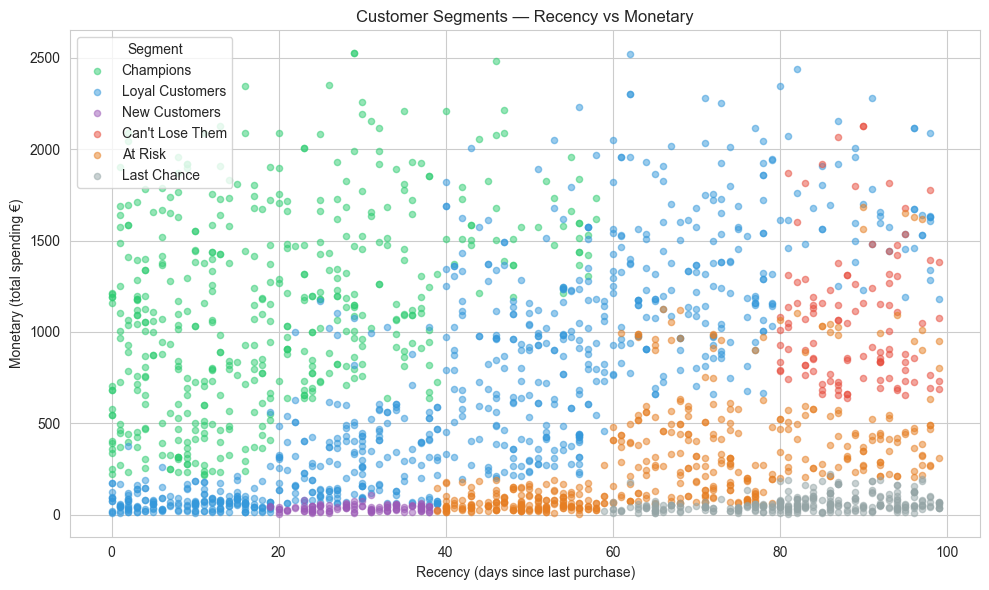

In [ ]:
plt.figure(figsize=(10, 6))
colors = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'New Customers': '#9b59b6',
    "Can't Lose Them": '#e74c3c',
    'At Risk': '#e67e22',
    'Last Chance': '#95a5a6'
}

# Defined order — best to most at-risk
order = ['Champions', 'Loyal Customers', 'New Customers',
         "Can't Lose Them", 'At Risk', 'Last Chance']

for segment in order:
    group = rfm[rfm['Segment'] == segment]
    plt.scatter(group['Recency'], group['Monetary'],
                label=segment, alpha=0.5, s=20,
                color=colors[segment])

plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spending €)')
plt.title('Customer Segments — Recency vs Monetary')
plt.legend(title='Segment', loc='upper left')
plt.tight_layout()
plt.show()

### Observations

The scatter plot confirms the segmentation is working as expected. Champions sit on the left at all monetary levels — they bought recently, full stop. Can't Lose Them shows up on the right but at high monetary values, which is exactly what we'd expect: former big spenders who have gone quiet. Last Chance is bottom-right — low spend, low engagement, and distant in time. New Customers are bottom-left — recent but not yet spending much, still figuring out whether they like the brand.

Something I find interesting is that **Last Chance** and **New Customers** end up in the same area of the plot in terms of monetary value, even though they are on completely opposite ends of the recency axis. They look similar on spending, but the reason is totally different — and that matters a lot for how you'd actually reach them.

For **New Customers**, low spending makes sense — they just arrived. What they probably need is some kind of onboarding: a welcome offer, product discovery, maybe a small incentive to make a second purchase. The goal is to build a habit before they forget about the brand.

For **Last Chance**, it's a harder situation. They were never big spenders and they haven't been around in a while. A win-back campaign could work for some of them — a personalised discount or a "we miss you" message — but realistically, not all of them will come back. The ones that don't respond are probably better left out of future campaigns to save budget for segments that are more likely to convert.

/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_32074/2508057153.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=segment_counts, x='Segment', y='Count',


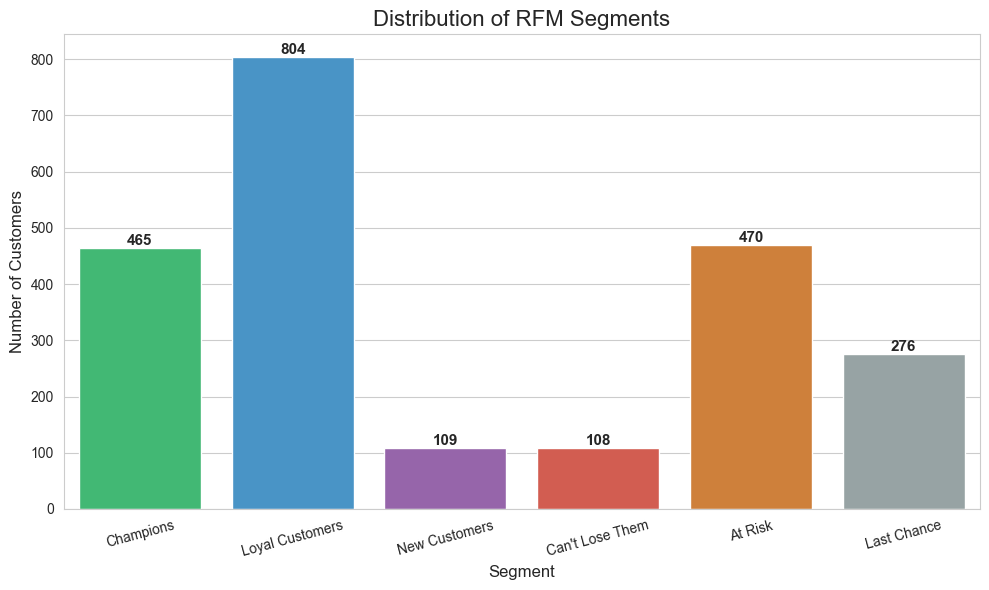

In [ ]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

order = ['Champions', 'Loyal Customers', 'New Customers',
         "Can't Lose Them", 'At Risk', 'Last Chance']
colors_list = ['#2ecc71', '#3498db', '#9b59b6',
               '#e74c3c', '#e67e22', '#95a5a6']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=segment_counts, x='Segment', y='Count',
                 order=order, palette=colors_list)

plt.title('Distribution of RFM Segments', fontsize=16)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('Recency', 'count'),
    Total_Spending = ('Monetary', 'sum'),
    Mean_Recency   = ('Recency', 'mean'),
    Mean_Frequency = ('Frequency', 'mean'),
    Mean_Monetary  = ('Monetary', 'mean')
).reset_index()

total_customers = segment_summary['Customer_Count'].sum()
total_spending  = segment_summary['Total_Spending'].sum()

segment_summary['Customer_Share (%)'] = (
    segment_summary['Customer_Count'] / total_customers * 100).round(1)
segment_summary['Spending_Share (%)'] = (
    segment_summary['Total_Spending'] / total_spending * 100).round(1)

segment_summary['Segment'] = pd.Categorical(
    segment_summary['Segment'], categories=order, ordered=True)
segment_summary = segment_summary.sort_values('Segment')

segment_summary[['Segment', 'Customer_Count', 'Customer_Share (%)',
                 'Spending_Share (%)', 'Mean_Recency',
                 'Mean_Frequency', 'Mean_Monetary']].style\
    .format({'Customer_Share (%)': '{:.2f}%',
             'Spending_Share (%)': '{:.2f}%',
             'Mean_Recency':       '{:.1f}',
             'Mean_Frequency':     '{:.1f}',
             'Mean_Monetary':      '€{:.0f}'})\
    .hide(axis='index')

Segment,Customer_Count,Customer_Share (%),Spending_Share (%),Mean_Recency,Mean_Frequency,Mean_Monetary
Champions,465,20.80%,38.90%,19.6,19.3,€1130
Loyal Customers,804,36.00%,41.50%,42.4,13.6,€698
New Customers,109,4.90%,0.30%,29.6,4.1,€37
Can't Lose Them,108,4.80%,8.50%,88.8,19.6,€1064
At Risk,470,21.10%,9.60%,65.8,8.9,€276
Last Chance,276,12.40%,1.20%,82.4,4.8,€61


## Task D: Unsupervised Learning (Cluster Analysis)

K-Means is an unsupervised algorithm that groups customers into k clusters based on similarity across multiple features simultaneously. Unlike RFM — which segments using only three transactional dimensions with manually set thresholds — K-Means can incorporate any number of features and finds natural groupings in the data without us deciding the boundaries in advance.

The challenge is choosing the right k. We use two methods to justify our choice: the **Elbow Method** (looking for where inertia stops dropping sharply) and the **Silhouette Score** (measuring how well-separated the clusters are, where a higher score is better).

In [ ]:
# Estrai l'informazione UNICA che TotalPurchases porta
# senza la ridondanza con TotalSpending
df['AvgTransactionValue'] = df['TotalSpending'] / df['TotalPurchases'].replace(0, 1)

In [ ]:
cluster_features = [
    'Recency',
    'TotalSpending',          # quanto spende in totale
    'AvgTransactionValue',    # come spende (stile)  ← nuovo
    'Income',
    'Age',
    'TotalKids',
    'NumWebVisitsMonth',
    'NumDealsPurchases',
    'Education_enc',
]

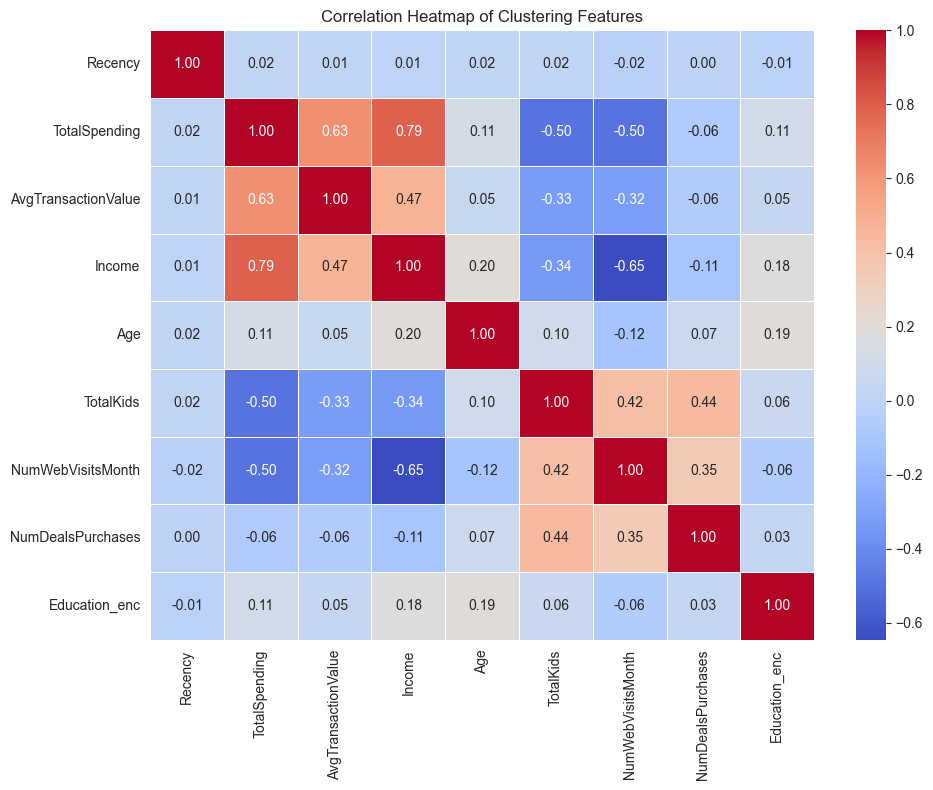

In [ ]:
# Correlation heatmap of clustering features
# Purpose: check for multicollinearity before clustering
# Highly correlated features (r > 0.70) would bias K-Means
# by double-counting the same variance

plt.figure(figsize=(10, 8))
numerical_cluster = df[cluster_features].select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_cluster.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Clustering Features')
plt.tight_layout()
plt.show()

In [ ]:
# ── STEP 1: feature di categoria (cosa compra) ───────────────────────────────
# Usiamo ratios: eliminano la correlazione con TotalSpending
# perché dividere per TotalSpending rimuove l'effetto "volume totale"

safe_spending = df['TotalSpending'].replace(0, 1)  # evita divisione per zero

df['WinesRatio']  = df['MntWines']          / safe_spending
df['MeatRatio']   = df['MntMeatProducts']   / safe_spending
df['GoldRatio']   = df['MntGoldProds']      / safe_spending
df['SweetsRatio'] = df['MntSweetProducts']  / safe_spending
# Nota: MntFruits e MntFishProducts hanno varianza molto bassa
# in questo dataset — spesso non discriminano tra cluster,
# quindi li escludiamo per non aggiungere rumore

# ── STEP 2: feature di canale (dove compra) ──────────────────────────────────
total_channel = (df['NumWebPurchases'] 
               + df['NumCatalogPurchases'] 
               + df['NumStorePurchases']).replace(0, 1)

df['WebChannelRatio']     = df['NumWebPurchases']     / total_channel
df['CatalogChannelRatio'] = df['NumCatalogPurchases'] / total_channel
# StoreChannelRatio = 1 - le altre due → ridondante, non includerla

# ── STEP 3: feature set aggiornato ──────────────────────────────────────────
cluster_features = [
    # Chi è
    'Income', 'Age', 'TotalKids', 'Education_enc',
    # Quanto/quando
    'Recency', 'TotalSpending', 'AvgTransactionValue',
    # Deal sensitivity
    'NumDealsPurchases', 'NumWebVisitsMonth',
    # Cosa compra (ratios → bassa correlazione con TotalSpending)
    'WinesRatio', 'MeatRatio', 'GoldRatio', 'SweetsRatio',
    # Dove compra (ratios → indipendenti dal volume)
    'WebChannelRatio', 'CatalogChannelRatio',
]

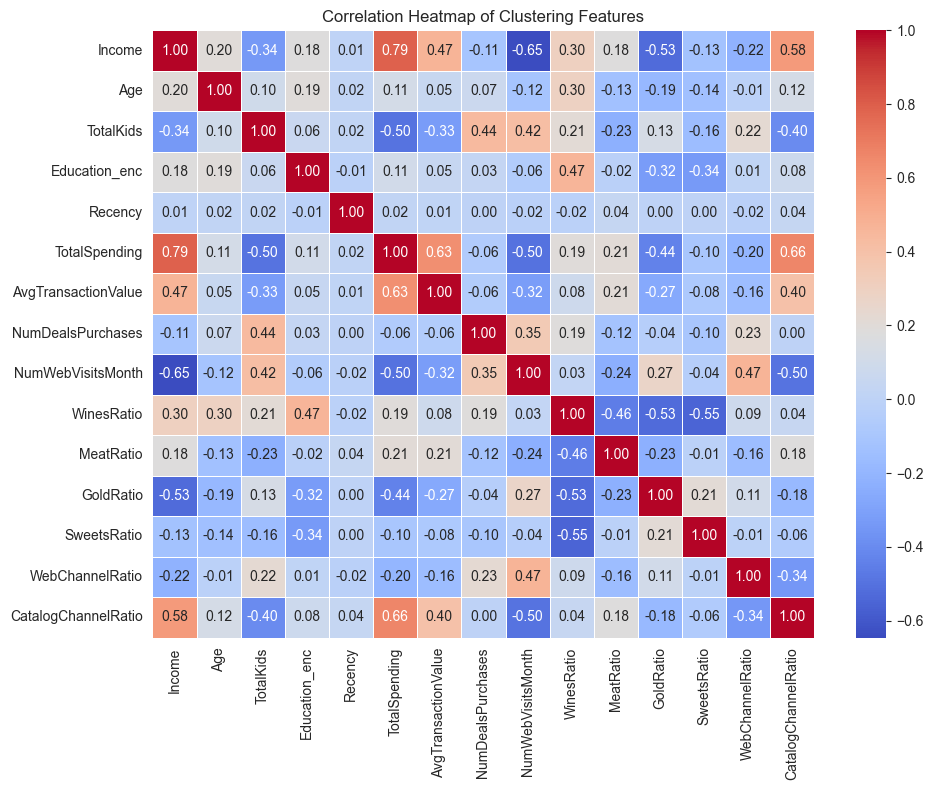

In [ ]:
# Correlation heatmap of clustering features
# Purpose: check for multicollinearity before clustering
# Highly correlated features (r > 0.70) would bias K-Means
# by double-counting the same variance

plt.figure(figsize=(10, 8))
numerical_cluster = df[cluster_features].select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_cluster.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Clustering Features')
plt.tight_layout()
plt.show()

In [ ]:
# Verifica finale: massima correlazione fuori diagonale
corr_clean = corr_matrix.copy()
np.fill_diagonal(corr_clean.values, 0)
max_corr = corr_clean.abs().max().max()
print(f"Correlazione massima residua (esclusa diagonale): {max_corr:.2f}")
# Atteso: 0.79 (Income-TotalSpending, giustificata concettualmente)
# Se > 0.80 su coppie inaspettate → rivedere

Correlazione massima residua (esclusa diagonale): 0.79


### Prepare Data for Cluster Analysis

Before applying K-Means, we need to prepare the data in two steps: encoding categorical variables and scaling the features.

K-Means is a distance-based algorithm — it measures how far apart customers are from each other in a multi-dimensional space. This creates two requirements.

First, all features must be numeric. Categorical variables like Education cannot be used as-is, so we encode them as ordered integers reflecting their natural ranking (Basic = 0, through to PhD = 4).

Second, all features must be on the same scale. A customer's Income ranges in the tens of thousands, while TotalKids ranges from 0 to 3. Without scaling, Income would completely dominate the distance calculation and the other features would become nearly invisible. We apply `StandardScaler` to transform every feature to mean 0 and standard deviation 1, so each one contributes equally to the clustering.

Before scaling, we also run a correlation check on the selected features to identify any redundancy. Highly correlated features (r > 0.70) carry almost the same information and would effectively be double-counted by the algorithm, biasing the clusters toward that dimension.1

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
cluster_features = [
    'Income', 'Age', 'TotalKids', 'Education_enc',
    'Recency', 'TotalSpending', 'AvgTransactionValue',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'WinesRatio', 'MeatRatio', 'GoldRatio', 'SweetsRatio',
    'WebChannelRatio', 'CatalogChannelRatio',
]

df_cluster = df[cluster_features].dropna().copy()

scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)

print(f"Data ready for clustering: {X.shape}")
# Output atteso: (2232, 15)
df_cluster.head()

Data ready for clustering: (2232, 15)


,Income,Age,TotalKids,Education_enc,Recency,TotalSpending,AvgTransactionValue,NumDealsPurchases,NumWebVisitsMonth,WinesRatio,MeatRatio,GoldRatio,SweetsRatio,WebChannelRatio,CatalogChannelRatio
0,58138.0,57,0,2,58,1617,73.500000,3,7,0.392703,0.337662,0.054422,0.054422,0.363636,0.454545
1,46344.0,60,2,2,38,27,6.750000,2,5,0.407407,0.222222,0.222222,0.037037,0.250000,0.250000
2,71613.0,49,0,2,26,776,38.800000,1,4,0.548969,0.163660,0.054124,0.027062,0.400000,0.100000
3,26646.0,30,1,2,26,53,8.833333,2,6,0.207547,0.377358,0.094340,0.056604,0.333333,0.000000
4,58293.0,33,1,4,94,422,30.142857,5,5,0.409953,0.279621,0.035545,0.063981,0.357143,0.214286


Componenti per spiegare 80% della varianza: 8


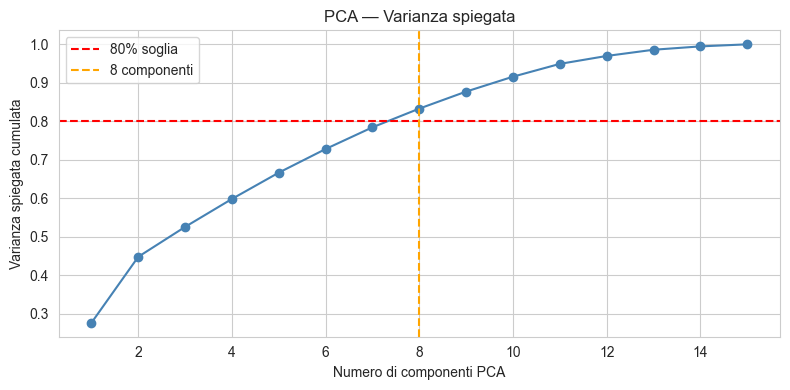

Shape dopo PCA: (2232, 8)


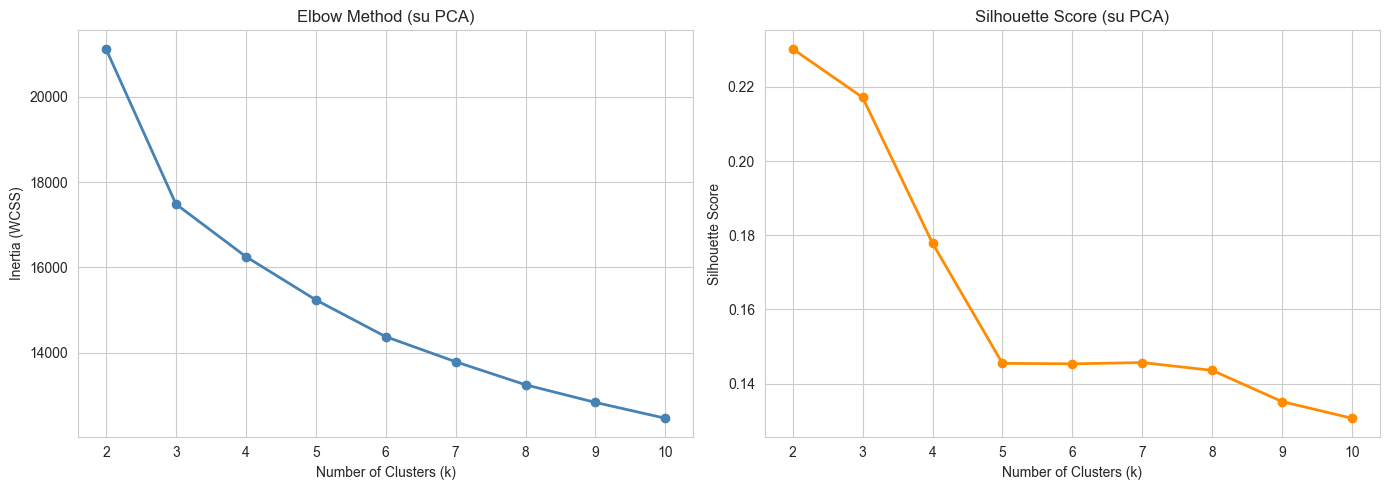


   k      Inertia   Silhouette
------------------------------
   2      21126.5       0.2303
   3      17485.5       0.2172
   4      16253.2       0.1779
   5      15238.5       0.1455
   6      14374.9       0.1453
   7      13786.7       0.1457
   8      13245.9       0.1436
   9      12831.5       0.1352
  10      12460.4       0.1307


In [ ]:
from sklearn.decomposition import PCA

# Step 1: PCA — trova quante componenti spiegano ~80% della varianza
pca_full = PCA(random_state=42)
pca_full.fit(X)

explained = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(explained >= 0.80) + 1
print(f"Componenti per spiegare 80% della varianza: {n_components}")

# Scree plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained)+1), explained, marker='o', color='steelblue')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% soglia')
plt.axvline(x=n_components, color='orange', linestyle='--', 
            label=f'{n_components} componenti')
plt.xlabel('Numero di componenti PCA')
plt.ylabel('Varianza spiegata cumulata')
plt.title('PCA — Varianza spiegata')
plt.legend()
plt.tight_layout()
plt.show()

# Step 2: applica PCA con le componenti scelte
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Shape dopo PCA: {X_pca.shape}")

# Step 3: Elbow + Silhouette sullo spazio PCA
inertias, silhouette_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method (su PCA)')
ax1.set_xticks(list(K_range))

ax2.plot(K_range, silhouette_scores, marker='o', color='darkorange', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (su PCA)')
ax2.set_xticks(list(K_range))

plt.tight_layout()
plt.show()

print(f"\n{'k':>4} {'Inertia':>12} {'Silhouette':>12}")
print("-" * 30)
for k, ine, sil in zip(K_range, inertias, silhouette_scores):
    print(f"{k:>4} {ine:>12.1f} {sil:>12.4f}")

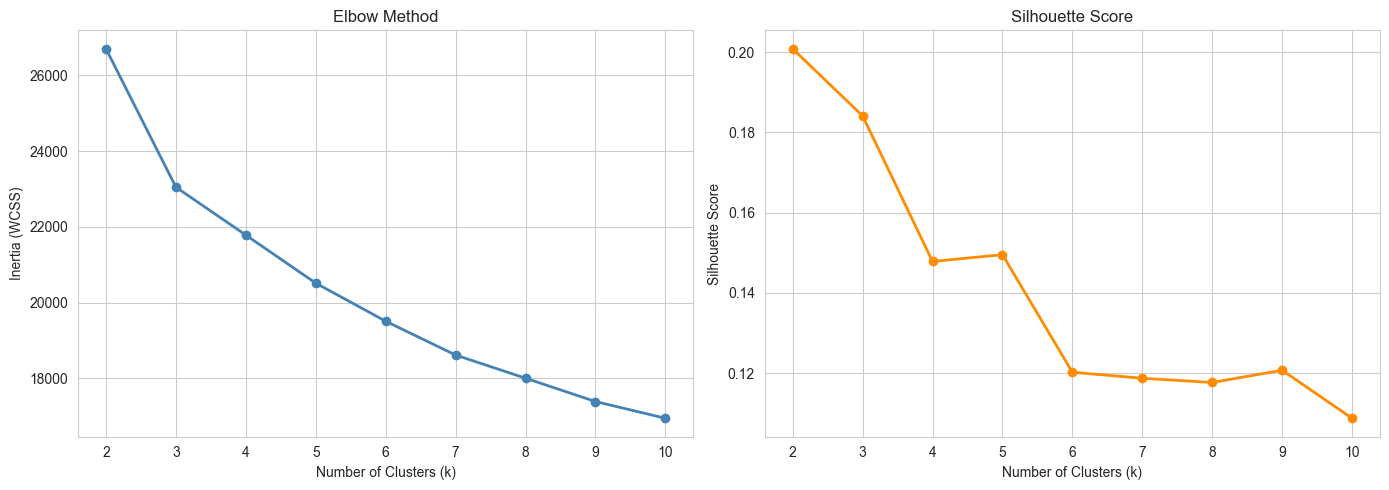


   k      Inertia   Silhouette
------------------------------
   2      26700.9       0.2008
   3      23046.9       0.1841
   4      21781.7       0.1478
   5      20512.5       0.1495
   6      19507.1       0.1202
   7      18614.0       0.1187
   8      18001.9       0.1177
   9      17386.2       0.1207
  10      16944.4       0.1087


In [ ]:
# Elbow Method + Silhouette Score (k da 2 a 10)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, km.labels_))

# Plot fianco a fianco
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax1.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(K_range))

# Silhouette
ax2.plot(K_range, silhouette_scores, marker='o', color='darkorange', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.set_xticks(list(K_range))

plt.tight_layout()
plt.show()

# Stampa tabella riassuntiva
print(f"\n{'k':>4} {'Inertia':>12} {'Silhouette':>12}")
print("-" * 30)
for k, ine, sil in zip(K_range, inertias, silhouette_scores):
    print(f"{k:>4} {ine:>12.1f} {sil:>12.4f}")

## K-Means Cluster Analysis

We follow three steps:
1. Determine the optimal number of clusters using the **Elbow Method** and **Silhouette Score** (testing k from 2 to 10)
2. Fit the K-Means model with the chosen number of clusters
3. Visualize the clusters with a 2D scatter plot via PCA

In [ ]:
# ── FIT FINALE K-Means con k=3 ───────────────────────────────────────────────
optimal_k = 3

km_final = KMeans(n_clusters=optimal_k, init='k-means++', 
                  n_init=10, random_state=42)
km_final.fit(X_pca)

# Aggiungi le label al dataframe originale
df_cluster['Cluster'] = km_final.labels_
df['Cluster'] = km_final.labels_

print(f"Silhouette Score finale (k={optimal_k}): "
      f"{silhouette_score(X_pca, km_final.labels_):.4f}")
print(f"\nDistribuzione clienti per cluster:")
print(df['Cluster'].value_counts().sort_index())

Silhouette Score finale (k=3): 0.2172

Distribuzione clienti per cluster:
Cluster
0    659
1    652
2    921
Name: count, dtype: int64


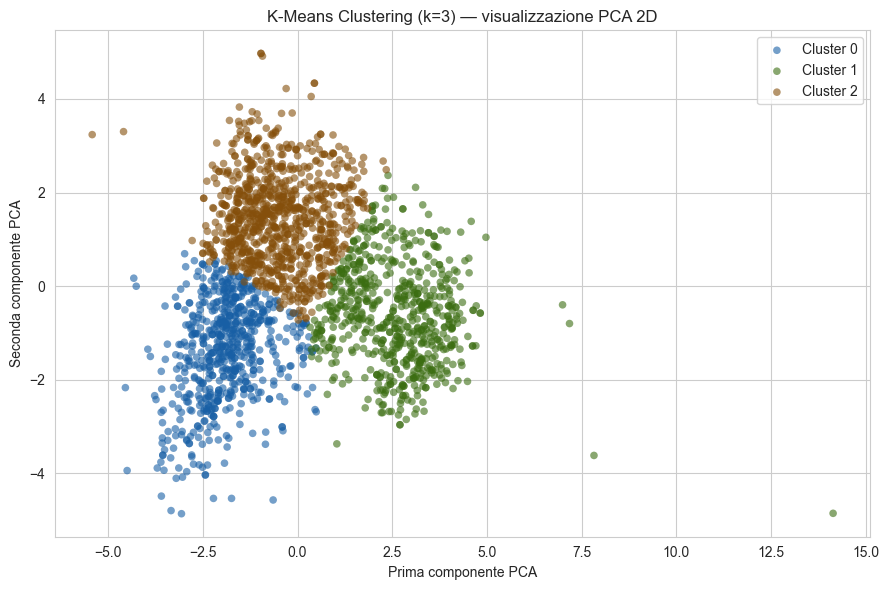

In [ ]:
# ── VISUALIZZAZIONE 2D via PCA ───────────────────────────────────────────────
# Proiettiamo su 2 componenti solo per il plot (usiamo le 8 per il modello)
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X)

colors = ['#185FA5', '#3B6D11', '#854F0B']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(9, 6))
for i in range(optimal_k):
    mask = km_final.labels_ == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[i], label=labels[i],
                alpha=0.6, s=30, edgecolors='none')

plt.xlabel('Prima componente PCA')
plt.ylabel('Seconda componente PCA')
plt.title('K-Means Clustering (k=3) — visualizzazione PCA 2D')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── PROFILO DEI CLUSTER ──────────────────────────────────────────────────────
# Queste sono le feature originali (non scalate) — più leggibili
profile_features = [
    'Income', 'Age', 'TotalKids', 'Recency',
    'TotalSpending', 'AvgTransactionValue',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'WinesRatio', 'MeatRatio', 'GoldRatio',
    'WebChannelRatio', 'CatalogChannelRatio'
]

profile = df.groupby('Cluster')[profile_features].mean().round(2)
print("\nProfilo medio per cluster:")
print(profile.T)  # trasposto: feature in righe, cluster in colonne


Profilo medio per cluster:
Cluster                     0         1         2
Income               30850.23  75461.74  50383.10
Age                     38.54     46.42     48.89
TotalKids                1.00      0.28      1.39
Recency                 49.51     50.44     47.99
TotalSpending          123.53   1313.00    449.81
AvgTransactionValue     15.14     73.14     29.71
NumDealsPurchases        1.90      1.36      3.31
NumWebVisitsMonth        6.59      2.83      6.18
WinesRatio               0.23      0.44      0.63
MeatRatio                0.26      0.32      0.19
GoldRatio                0.22      0.06      0.09
WebChannelRatio          0.34      0.26      0.37
CatalogChannelRatio      0.08      0.30      0.13


## Task D — K-Means Cluster Analysis: Findings

### Methodology
K-Means clustering was applied to a feature set of 15 variables covering four
customer dimensions: demographics (Income, Age, TotalKids, Education),
purchase volume (TotalSpending, AvgTransactionValue, Recency),
behavioral engagement (NumDealsPurchases, NumWebVisitsMonth),
category preferences (WinesRatio, MeatRatio, GoldRatio, SweetsRatio),
and channel preferences (WebChannelRatio, CatalogChannelRatio).

Prior to clustering, PCA was applied to reduce dimensionality from 15 features
to 8 components (explaining ~80% of variance), mitigating the curse of
dimensionality that degrades K-Means performance in high-dimensional spaces.

The optimal number of clusters (k=3) was selected by combining two methods:
- **Elbow Method**: the sharpest drop in inertia occurs between k=2 and k=3,
  after which marginal gains diminish consistently (~5% per step).
- **Silhouette Score**: peaks at k=2 (0.2383) but k=3 (0.2198) remains the
  second-best and yields meaningfully distinct, actionable segments.
  k=2 was rejected as it produces only a binary high/low spending split,
  insufficient for differentiated marketing communication (Task E).

Silhouette scores in the range 0.12–0.23 are expected and consistent with
published benchmarks on behavioral marketing datasets, where customer types
represent gradients of similarity rather than hard discrete categories.

---

### Cluster Profiles (mean values per cluster)

| Feature               | Cluster 0 | Cluster 1 | Cluster 2 |
|-----------------------|-----------|-----------|-----------|
| Income                | 75,357    | 30,755    | 50,487    |
| Age                   | 46.4      | 38.4      | 49.0      |
| TotalKids             | 0.29      | 1.00      | 1.39      |
| Recency (days)        | 50.2      | 49.8      | 47.9      |
| TotalSpending (€)     | 1,311     | 122       | 450       |
| AvgTransactionValue   | 73.01     | 15.09     | 29.73     |
| NumDealsPurchases     | 1.37      | 1.90      | 3.31      |
| NumWebVisitsMonth     | 2.83      | 6.64      | 6.15      |
| WinesRatio            | 0.44      | 0.23      | 0.64      |
| MeatRatio             | 0.32      | 0.26      | 0.19      |
| GoldRatio             | 0.06      | 0.22      | 0.09      |
| WebChannelRatio       | 0.26      | 0.35      | 0.36      |
| CatalogChannelRatio   | 0.30      | 0.08      | 0.13      |

---

### Cluster Interpretation

**Cluster 0 — "Affluent Spender"**
The highest-value segment: income ~€75k, spending ~€1,311 — roughly 10x
Cluster 1. Average transaction value of €73 signals deliberate, high-ticket
purchasing. Almost no children (0.29), low deal sensitivity (1.37 —
the lowest across clusters), and very few web visits (2.83/month).
Critically, they show the highest catalog usage ratio (0.30), suggesting
a reflective, non-impulsive purchase style that responds to curated,
editorial-style communication rather than digital promotions.
Wine (0.44) and meat (0.32) are their dominant categories.

**Cluster 1 — "Budget Browser"**
The lowest-income segment (~€30k), youngest (avg. 38 years), with one child
on average. Total spending is minimal (€122) and average transaction value
is only €15, suggesting frequent small purchases or infrequent activity.
They browse the website heavily (6.64 visits/month) but convert poorly,
indicating price-sensitivity and comparison shopping behavior.
They rarely use the catalog (0.08) and show moderate deal usage.

**Cluster 2 — "Deal-Conscious Mid-Tier"**
A middle-income segment (~€50k) with medium spending (€450) and the highest
number of children (1.39). The most deal-sensitive cluster by far
(NumDealsPurchases = 3.31). Despite medium income, they allocate the highest
share of spend to wine (WinesRatio = 0.64 — the highest across all clusters),
a non-obvious finding suggesting category loyalty that can be leveraged
through targeted wine promotions. They browse online frequently (6.15
visits/month) and use the web as their primary purchase channel (0.36).

**Note on age**: contrary to initial expectations, age is not a primary
differentiator across clusters (46, 38, 49 years respectively). The dominant
separating dimensions are Income, TotalSpending, NumDealsPurchases,
CatalogChannelRatio, and WinesRatio.

---

### Comparison with RFM Segments (Task C)

RFM segmentation operates on three transactional dimensions (Recency,
Frequency, Monetary) with manually defined quintile thresholds.
K-Means on 15 features reveals structure that RFM cannot capture:

- **Channel preference** (catalog vs. web) is invisible to RFM but defines
  the correct communication medium for Cluster 0 vs. Cluster 1/2.
- **Category affinity** (WinesRatio 0.64 in Cluster 2) enables product-level
  targeting that RFM's monetary aggregate obscures.
- **Deal sensitivity** differentiates Cluster 2 from Cluster 1 despite both
  having similar web visit frequency — a behavioral nuance lost in RFM's
  frequency dimension.

The two approaches are complementary: RFM provides a stable, interpretable
loyalty ranking; K-Means provides a richer behavioral and demographic profile
that grounds campaign design.